# Quantum gates and circuits — the digital viewpoint

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 4 — Digital quantum circuits*

## 1. Introduction and motivation

In the previous notebooks we simulated **spin chains**: we stored the state of $N$ spins-1/2 as a rank-$N$ tensor,
we learned to act on it with small matrices through one `einsum` (the function `apply_gate` of
[notebook 05](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb)), and we evolved it in time by chopping $e^{-iHt}$ into a product of
many small two-spin unitaries (Trotterization, [notebook 04](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb)).

*A product of many small unitaries acting on a register of two-level systems* is, word for word, the definition of a
**quantum circuit**. A quantum computer is a many-body spin system in
which the experimentalist can switch the terms of the Hamiltonian on and off at will: a laser or microwave pulse on one
atom/ion/superconducting island is a *single-qubit gate*, a controlled interaction between two of them, left on for
a calibrated time, is a *two-qubit gate*. The "digital" language of gates and circuits used by the quantum-computing
community and the "analog" language of Hamiltonians used in many-body physics describe the same mathematics.

This notebook makes the translation explicit, so that both literatures can be read side by side. Its first
consequence is that **we already own a quantum-circuit simulator**: it is `apply_gate` plus a Python list.

**Gates in many-body physics.**

* *Digital quantum simulation*: present-day quantum processors (superconducting qubits, trapped ions, Rydberg-atom
  arrays) simulate spin models by running Trotter circuits. To understand those experiments, and their errors, you
  need to be able to count gates and to model noise.
* *State preparation*: GHZ states, cluster states, squeezed states, variational ansätze (Chapter 11) are
  all defined by the circuits that prepare them.
* *Numerics*: thinking in gates is the natural way of organising fast simulation code. Every algorithm of this
  course - TEBD, quantum trajectories, classical shadows, variational eigensolvers - is "a loop over small einsums".

**Road map.** Section 2 is a dictionary between spin and qubit language. Section 3 introduces the single-qubit gates
and *derives* the rotation gates $R_x, R_y, R_z$ as exponentials of Pauli matrices. Section 4 treats the two-qubit
gates (CNOT, CZ, SWAP, controlled-$U$, $R_{xx}, R_{yy}, R_{zz}$) and the three-qubit Toffoli/CCZ. In Section 5 a
circuit becomes a Python list, we draw it, compute its depth and prepare Bell, GHZ and cluster states. Section 6
compiles whole circuits with `jax.jit`, sweeps parameters with `vmap` and folds deep circuits with `lax.scan`.
Section 7 verifies the standard circuit identities numerically, Section 8 comments on universality (with a small
numerical experiment), Section 9 rewrites a Trotter step of the transverse-field Ising model as a circuit and counts
its gates, and Section 10 runs circuits with noise after each gate on the density tensor
([notebook 07](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)).

### What you will learn

*Physics*

* the gate set of digital quantum devices and its physical origin (pulses = rotations, interactions = entangling gates);
* rotations of the Bloch sphere as exponentials of Pauli operators; global versus relative phases;
* how entanglement is created by a circuit (Bell, GHZ, cluster states);
* a Trotter step of a spin chain *is* a circuit; the trade-off between Trotter error and gate noise.

*Numerical methods*

* closed forms of matrix exponentials from the property $P^2=1$ and their validation against a generic `expm`;
* the dense unitary of a circuit obtained from the matrix-free action on basis states (for validation only);
* gate counting, circuit depth (greedy scheduling), cost $O(2^k 2^N)$ per $k$-qubit gate;
* noisy circuits on the density tensor, cross-checked with quantum trajectories.

*Implementation practice*

* a circuit as plain data: a list of `(qubits, U)`; pure functions that build and run it;
* `jax.jit` of a whole circuit (compile time versus run time), `jax.vmap` over gate angles, `lax.scan` over layers,
  `lax.fori_loop` with a traced number of steps;
* comparing unitaries "up to a global phase" with a robust numerical criterion.

### Prerequisites

* [01 JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) (`jit`, `vmap`, `scan`, PRNG keys),
  [02 einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb);
* [03 Many-body spin systems](../ch02_spin_systems_textbook_way/03_quantum_many_body_spin_systems.ipynb) (Pauli matrices, Kronecker products, bit-string
  labelling) and [04 Time evolution the textbook way](../ch02_spin_systems_textbook_way/04_time_evolution_the_textbook_way.ipynb) (Trotterization);
* [05 Matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): the primitive `apply_gate` - **the** prerequisite;
* [06 States, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) (reduced density matrices,
  entanglement entropy), [07 Density matrices and channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)
  (Kraus channels, trajectories) for Sections 5 and 10.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Spins are qubits: a dictionary

A **qubit** is any quantum two-level system used to carry information; mathematically it is a spin-1/2. The two
communities use different words for the same objects:

| many-body physics (notebooks 03-05) | quantum computing (this notebook) |
|---|---|
| spin-1/2 at site $q$, states $\lvert\uparrow\rangle,\lvert\downarrow\rangle$ | qubit $q$, states $\lvert 0\rangle = (1,0)^T$, $\lvert 1\rangle = (0,1)^T$ |
| product basis $\lvert\uparrow\downarrow\uparrow\rangle$ | computational basis $\lvert 010\rangle$ (a *bit string*) |
| Pauli matrices $\sigma^x,\sigma^y,\sigma^z$ | gates $X, Y, Z$ |
| local unitary $e^{-i\tau h}$ generated by a one- or two-site term $h$ | one- or two-qubit **gate** $U$ |
| evolution for a short time under a sequence of terms | **circuit**: an ordered list of gates |
| number of Trotter steps | circuit **depth** |
| state tensor `psi[s_0, ..., s_{N-1}]` | *the same tensor* - "register of $N$ qubits" |

Conventions (unchanged throughout the course): qubit $q$ is tensor axis $q$, counted from 0; $\lvert 0\rangle$ is the
$+1$ eigenstate of $Z$ ("spin up"); the flat index of a basis state is the bit string read as a binary number with
qubit 0 as the most significant bit, $i = s_0 2^{N-1} + \dots + s_{N-1}$.

**Recap of the one primitive we need.** Applying a $2\times2$ matrix $U$ to qubit $q$ of an $N$-qubit state is the
contraction

$$ \psi'_{s_0 \dots a \dots s_{N-1}} = \sum_{b} U_{ab}\, \psi_{s_0 \dots b \dots s_{N-1}} , $$

and for a $4\times4$ matrix on qubits $(q_1,q_2)$ we first reshape $U \to U_{a_1 a_2 b_1 b_2}$ and contract two
axes. For $N=3$, $q=1$ the einsum string is `"Ab,abc->aAc"`. Cost: $O(2^k 2^N)$ for a $k$-qubit gate, no
$2^N\times2^N$ matrix ever appears. All of this was derived in notebook 05; the cell below (folded on the website)
recalls the production code of the primitives used in this notebook.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def basis_state(bits):
    """Computational basis state |b_0 b_1 ... b_{N-1}> from a list of bits."""
    bits = tuple(int(b) for b in bits)
    return jnp.zeros((2,) * len(bits), dtype=CDTYPE).at[bits].set(1.0)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))

def all_local_expectations(psi):
    """Bloch vectors of all qubits: array (N,3) with rows (<X_q>, <Y_q>, <Z_q>), from the 1-qubit RDMs."""
    out = []
    for q in range(psi.ndim):
        r = rdm(psi, [q])
        out.append(jnp.stack([jnp.real(jnp.trace(r @ P)) for P in (X, Y, Z)]))
    return jnp.stack(out)


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def _expm_herm(h, tau):
    """exp(-i tau h) for a SMALL Hermitian matrix: h = V w V^dag  =>  V exp(-i tau w) V^dag."""
    w, v = jnp.linalg.eigh(jnp.asarray(h, dtype=CDTYPE))
    return (v * jnp.exp(-1j * tau * w)) @ v.conj().T

def tebd_gates(terms, dt, order=2):
    """Gate sequence of ONE Trotter-Suzuki (TEBD) step for H = sum_k h_k.

    MATH   exp(-i H dt) cannot be split exactly because [h_k, h_l] != 0, but (BCH formula):
        order 1:  prod_k e^{-i h_k dt}                                       local error O(dt^2), global O(dt)
        order 2:  prod_k e^{-i h_k dt/2} * prod_k(reversed) e^{-i h_k dt/2}  local O(dt^3), global O(dt^2)
        order 4:  S2(s dt)^2 S2((1-4s) dt) S2(s dt)^2,  s = 1/(4 - 4^{1/3})  (Suzuki)   global O(dt^4)
    Each factor is a 2x2 or 4x4 unitary -> applied by einsum; this is TEBD on a full state vector.
    Every order is exactly unitary: the norm is conserved to machine precision; the ERROR is in the phase
    /direction of the state, and it is controlled by dt.
    """
    if order == 1:
        return [(q, _expm_herm(h, dt)) for q, h in terms]
    if order == 2:
        half = [(q, _expm_herm(h, dt / 2)) for q, h in terms]
        return half + half[::-1]
    if order == 4:
        s = 1.0 / (4.0 - 4.0 ** (1.0 / 3.0))
        seq = []
        for w in (s, s, 1 - 4 * s, s, s):
            seq += tebd_gates(terms, w * dt, order=2)
        return seq
    raise ValueError("order must be 1, 2 or 4")

def exact_evolve(psi, terms, t):
    """Dense reference for small N: full diagonalisation H = V w V^dag, |psi(t)> = V e^{-i w t} V^dag |psi>.
    O(8^N) time, O(4^N) memory -- the wall that matrix-free methods avoid; used only to validate them."""
    N = psi.ndim
    w, v = jnp.linalg.eigh(dense_hamiltonian(terms, N))
    return ((v * jnp.exp(-1j * t * w)) @ (v.conj().T @ psi.reshape(-1))).reshape((2,) * N)


# ----------------------------------------------------------------------------
# 12. Random unitaries, Clifford group, brick-wall circuits
# ----------------------------------------------------------------------------
def single_qubit_cliffords():
    """The 24 single-qubit Clifford gates (modulo global phase), generated by closing {H, S} under
    multiplication (breadth-first search; a canonical phase makes matrices comparable)."""
    found = [np.eye(2, dtype=complex)]
    gens = [np.asarray(H), np.asarray(S)]

    def canon(U):
        i = np.flatnonzero(np.abs(U.reshape(-1)) > 1e-9)[0]
        return U * np.exp(-1j * np.angle(U.reshape(-1)[i]))

    frontier = [found[0]]
    while frontier:
        nxt = []
        for U in frontier:
            for g in gens:
                V = canon(g @ U)
                if not any(np.allclose(V, W) for W in found):
                    found.append(V)
                    nxt.append(V)
        frontier = nxt
    return jnp.asarray(np.stack(found), dtype=CDTYPE)


## 3. Single-qubit gates

### 3.1 The fixed gates: Paulis, Hadamard, $S$ and $T$

A single-qubit gate is a $2\times 2$ unitary matrix, $U^\dagger U = 1$. The ones with a name are

| gate | matrix | what it does |
|---|---|---|
| $X$ | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | bit flip $\lvert0\rangle\leftrightarrow\lvert1\rangle$ (NOT gate; a $\pi$ rotation about $x$) |
| $Y$ | $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$ | bit flip and phase flip |
| $Z$ | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | phase flip $\lvert1\rangle\to-\lvert1\rangle$ |
| $H$ (Hadamard) | $\frac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | basis change $Z\leftrightarrow X$: $\lvert0\rangle\to\lvert+\rangle$, $\lvert1\rangle\to\lvert-\rangle$ |
| $S$ (phase gate) | $\begin{pmatrix}1&0\\0&i\end{pmatrix}$ | quarter turn about $z$; $S^2 = Z$ |
| $T$ ($\pi/8$ gate) | $\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}$ | eighth of a turn about $z$; $T^2 = S$ |

with $\lvert\pm\rangle = (\lvert0\rangle\pm\lvert1\rangle)/\sqrt2$ the eigenstates of $X$. These matrices are constants of
our engine; here they are, verbatim. **Beware of the names**: in this notebook `H` is the Hadamard gate (not a
Hamiltonian), `S` and `T` are gates (not an entropy and a time), so we must avoid these letters for other variables.

In [3]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
TDG = T.conj().T
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|


**Checkpoint.** Before using any gate we test the properties claimed in the table: unitarity, $H^2=1$, $S^2=Z$,
$T^2=S$, and the action of $H$ on the basis states. `TOL` is the tolerance defined in the configuration cell
($10^{-10}$ in double precision).

In [4]:
# ==============================================================================
# CHECKPOINT: elementary properties of the fixed single-qubit gates
# ==============================================================================
named_1q = {"I": I2, "X": X, "Y": Y, "Z": Z, "H": H, "S": S, "T": T}

for name, U in named_1q.items():
    err = float(jnp.max(jnp.abs(U.conj().T @ U - I2)))          # || U^dag U - 1 ||_max
    assert err < TOL, name
print("all seven gates are unitary")

checks = {"H H = 1": (H @ H, I2), "S S = Z": (S @ S, Z), "T T = S": (T @ T, S),
          "X Y = i Z": (X @ Y, 1j * Z), "S^dag S = 1": (SDG @ S, I2)}
for text, (lhs, rhs) in checks.items():
    err = float(jnp.max(jnp.abs(lhs - rhs)))
    print(f"{text:12s}  max error = {err:.1e}")
    assert err < TOL

ket0 = jnp.array([1, 0], dtype=CDTYPE)
print("H|0> =", np.round(np.asarray(H @ ket0), 4), "  = |+>")

all seven gates are unitary
H H = 1       max error = 2.2e-16
S S = Z       max error = 0.0e+00
T T = S       max error = 2.2e-16
X Y = i Z     max error = 0.0e+00
S^dag S = 1   max error = 0.0e+00
H|0> = [0.7071+0.j 0.7071+0.j]   = |+>


All identities hold to machine precision, and $H\lvert0\rangle$ has two equal amplitudes $1/\sqrt2 \approx 0.7071$:
the Hadamard gate creates the equal superposition $\lvert+\rangle$.

### 3.2 Rotations as exponentials of Pauli matrices

The fixed gates above are special cases of a continuous family. Physically, a gate is implemented by switching on a
Hamiltonian for some time: a resonant driving field along $x$ with Rabi frequency $\Omega$ is described (in the
rotating frame, $\hbar=1$) by $H_{\rm drive} = \frac{\Omega}{2} X$, and after a time $t$ the qubit has evolved by

$$ U(t) = e^{-iH_{\rm drive}t} = e^{-i\,\theta X/2}, \qquad \theta=\Omega t . $$

The pulse *area* $\theta$ is the parameter of the gate. This motivates the definition of the **rotation gates**

$$ R_x(\theta) = e^{-i\theta X/2},\qquad R_y(\theta) = e^{-i\theta Y/2},\qquad R_z(\theta) = e^{-i\theta Z/2}. \tag{1}$$

A matrix exponential is defined by its power series, $e^{A} = \sum_{k=0}^\infty A^k/k!$. In general one needs a
numerical algorithm to evaluate it, but for Pauli matrices there is a closed form. Let $P$ be any matrix with
$P^2 = 1$ (true for $X$, $Y$, $Z$ and, as we will need later, for $X\otimes X$ etc.). Then $P^{2m}=1$ and
$P^{2m+1}=P$, so the series splits into even and odd powers:

$$ e^{-i a P} = \sum_{m}\frac{(-ia)^{2m}}{(2m)!}\,1 + \sum_m \frac{(-ia)^{2m+1}}{(2m+1)!}\,P
             = \Big(\sum_m \frac{(-1)^m a^{2m}}{(2m)!}\Big) 1 - i\Big(\sum_m\frac{(-1)^m a^{2m+1}}{(2m+1)!}\Big)P , $$

where we used $(-i)^{2m} = (-1)^m$ and $(-i)^{2m+1} = -i(-1)^m$. We recognise the series of cosine and sine:

$$ \boxed{\,e^{-iaP} = \cos(a)\,1 - i \sin(a)\,P \qquad\text{if } P^2=1.\,} \tag{2}$$

This is the matrix version of Euler's formula $e^{-ia} = \cos a - i \sin a$. With $a=\theta/2$ we obtain

$$ R_x(\theta) = \begin{pmatrix}\cos\frac\theta2 & -i\sin\frac\theta2\\ -i\sin\frac\theta2&\cos\frac\theta2\end{pmatrix},\quad
   R_y(\theta) = \begin{pmatrix}\cos\frac\theta2 & -\sin\frac\theta2\\ \sin\frac\theta2&\cos\frac\theta2\end{pmatrix},\quad
   R_z(\theta) = \begin{pmatrix}e^{-i\theta/2} & 0\\0& e^{i\theta/2}\end{pmatrix}. \tag{3}$$

More generally, for a unit vector $\mathbf n$ the matrix $\mathbf n\cdot\boldsymbol\sigma = n_xX+n_yY+n_zZ$ also
squares to one (because different Pauli matrices anticommute and $|\mathbf n|=1$), hence
$R_{\mathbf n}(\theta) = e^{-i\theta\,\mathbf n\cdot\boldsymbol\sigma/2} = \cos\frac\theta2 - i\sin\frac\theta2\,\mathbf n\cdot\boldsymbol\sigma$.

**From formula to code.** We implement Eq. (2) literally (`pauli_rotation`) and compare it with two independent
evaluations of the exponential: (i) the truncated power series, to watch it converge, and (ii) the general-purpose
`jax.scipy.linalg.expm`.

In [5]:
# ==============================================================================
# STEP 1: exp(-i theta P / 2) three ways: closed form, power series, generic expm
# ==============================================================================
from jax.scipy.linalg import expm


def pauli_rotation(theta, P):
    """Rotation generated by an involutory matrix P (P @ P = 1).

    MATH   exp(-i theta P / 2) = cos(theta/2) 1 - i sin(theta/2) P          [Eq. (2) with a = theta/2]
    Works for P = X, Y, Z, n.sigma, and for two-qubit Pauli products like X(x)X.
    """
    d = P.shape[0]
    return jnp.cos(theta / 2) * jnp.eye(d, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * P


def exp_series(A, K):
    """Truncated power series  sum_{k<K} A^k / k!   (for demonstration only: slow and inaccurate for large ||A||)."""
    term = jnp.eye(A.shape[0], dtype=CDTYPE)
    total = term
    for k in range(1, K):
        term = term @ A / k                  # A^k/k! from A^(k-1)/(k-1)!
        total = total + term
    return total


theta = 1.234
for name, P in (("X", X), ("Y", Y), ("Z", Z)):
    closed = pauli_rotation(theta, P)
    generic = expm(-0.5j * theta * P)
    err = float(jnp.max(jnp.abs(closed - generic)))
    print(f"R_{name.lower()}({theta}):  |closed form - expm|_max = {err:.1e}")
    assert err < TOL

print("\nconvergence of the power series for R_y(1.234):")
for K in (2, 4, 6, 8, 12, 16):
    err = float(jnp.max(jnp.abs(exp_series(-0.5j * theta * Y, K) - pauli_rotation(theta, Y))))
    print(f"   {K:2d} terms: error = {err:.1e}")

R_x(1.234):  |closed form - expm|_max = 1.1e-16
R_y(1.234):  |closed form - expm|_max = 1.1e-16
R_z(1.234):  |closed form - expm|_max = 0.0e+00

convergence of the power series for R_y(1.234):
    2 terms: error = 1.8e-01
    4 terms: error = 6.0e-03
    6 terms: error = 7.6e-05
    8 terms: error = 5.2e-07
   12 terms: error = 6.3e-12
   16 terms: error = 0.0e+00


The closed form agrees with the generic matrix exponential to machine precision, and the power series converges
factorially fast to the same matrix (about 16 terms are needed for $\theta\approx1.2$ in double precision). The closed form is
preferable: it is exact, costs two trigonometric functions, and is differentiable with respect to $\theta$ - which is
what variational algorithms ([notebook 40](../ch11_variational_quantum_circuits/40_parametrized_gates_and_gradients.ipynb),
Chapter 11) need.

The engine versions of the three rotations are the matrices of Eq. (3) written out explicitly. `theta` may be a
*traced* JAX scalar, so these functions can live inside `jit`, `vmap` and `grad`.

In [6]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


### 3.3 Checkpoint on the Bloch sphere

The name "rotation" refers to the Bloch sphere. Every pure qubit state can be written as
$\lvert\psi\rangle = \cos\frac\vartheta2\lvert0\rangle + e^{i\varphi}\sin\frac\vartheta2\lvert1\rangle$ and is represented by the
**Bloch vector** $\mathbf r = (\langle X\rangle,\langle Y\rangle,\langle Z\rangle) = (\sin\vartheta\cos\varphi,\ \sin\vartheta\sin\varphi,\ \cos\vartheta)$
(notebook 03). Apply $R_z(\theta)$ from Eq. (3):

$$ R_z(\theta)\lvert\psi\rangle = e^{-i\theta/2}\Big(\cos\tfrac\vartheta2\lvert0\rangle + e^{i(\varphi+\theta)}\sin\tfrac\vartheta2\lvert1\rangle\Big). $$

The overall factor $e^{-i\theta/2}$ is a global phase without any observable consequence; what remains is
$\varphi\to\varphi+\theta$: the Bloch vector has been rotated by the angle $\theta$ about the $z$ axis
(counter-clockwise when seen from the tip of the axis). The same holds for any axis: $R_{\mathbf n}(\theta)$ rotates
the Bloch vector by $\theta$ about $\mathbf n$. (We quote this general statement without proof; it follows from the
identity $R^\dagger (\mathbf r\cdot\boldsymbol\sigma) R = (\mathcal R^{-1}\mathbf r)\cdot\boldsymbol\sigma$, see Nielsen & Chuang, Sec. 4.2.)

Prediction to test: starting from $\lvert0\rangle$, i.e. $\mathbf r=(0,0,1)$, a rotation about $x$ by $\theta$ must give
$\mathbf r(\theta) = (0, -\sin\theta, \cos\theta)$, and a rotation about $y$ gives $(\sin\theta, 0, \cos\theta)$.

**From formula to code.** One function maps an angle to a Bloch vector: build $\lvert0\rangle$, apply the gate with
`apply_gate`, read out $(\langle X\rangle,\langle Y\rangle,\langle Z\rangle)$ from the one-qubit reduced density matrix
(`all_local_expectations`). `jax.vmap` turns this function of *one* angle into a function of a whole array of angles
without a Python loop (notebook 01), and `jax.jit` compiles the batched function.

max deviation from (0,-sin,cos) for R_x: 2.2e-16
max deviation from (sin,0,cos)  for R_y: 2.2e-16


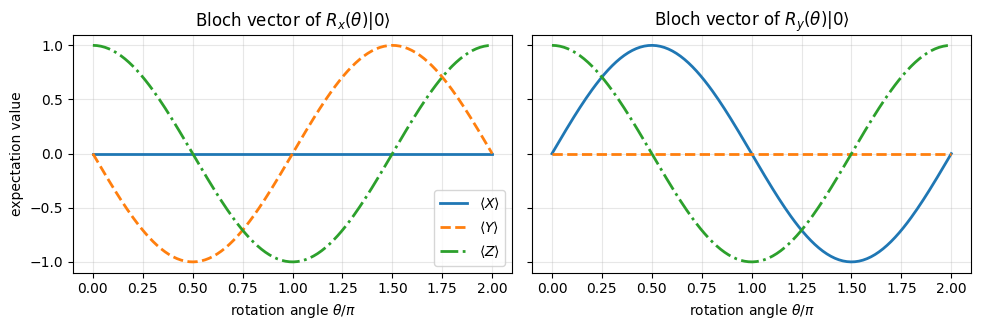

In [7]:
# ==============================================================================
# STEP 2: Bloch vector of R_x(theta)|0> and R_y(theta)|0> for 200 angles at once (vmap)
# ==============================================================================
def bloch_after(gate_fn, theta):
    """Bloch vector (<X>,<Y>,<Z>) of gate_fn(theta)|0>."""
    psi = apply_gate(zero_state(1), gate_fn(theta), [0])
    return all_local_expectations(psi)[0]


thetas = jnp.linspace(0.0, 2 * jnp.pi, 200)
bloch_x = jax.jit(jax.vmap(lambda th: bloch_after(rx, th)))(thetas)      # shape (200, 3)
bloch_y = jax.jit(jax.vmap(lambda th: bloch_after(ry, th)))(thetas)

# CHECKPOINT against the analytic rotation of the Bloch vector
zeros = jnp.zeros_like(thetas)
err_x = float(jnp.max(jnp.abs(bloch_x - jnp.stack([zeros, -jnp.sin(thetas), jnp.cos(thetas)], axis=1))))
err_y = float(jnp.max(jnp.abs(bloch_y - jnp.stack([jnp.sin(thetas), zeros, jnp.cos(thetas)], axis=1))))
print(f"max deviation from (0,-sin,cos) for R_x: {err_x:.1e}")
print(f"max deviation from (sin,0,cos)  for R_y: {err_y:.1e}")
assert max(err_x, err_y) < 10 * TOL

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, data, name in zip(axes, (bloch_x, bloch_y), ("R_x", "R_y")):
    for k, (lab, ls) in enumerate(zip((r"$\langle X\rangle$", r"$\langle Y\rangle$", r"$\langle Z\rangle$"), ("-", "--", "-."))):
        ax.plot(thetas / jnp.pi, data[:, k], ls, lw=2, label=lab)
    ax.set_xlabel(r"rotation angle $\theta/\pi$")
    ax.set_title(rf"Bloch vector of ${name}(\theta)|0\rangle$")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("expectation value")
axes[0].legend()
plt.tight_layout()
plt.show()

The numerical Bloch vectors follow the predicted great circles: $R_x$ moves the vector in the $y$-$z$ plane
($\langle Y\rangle=-\sin\theta$), $R_y$ in the $x$-$z$ plane. At $\theta=\pi$ the spin is flipped
($\langle Z\rangle=-1$): a "$\pi$ pulse" is an $X$ gate. At $\theta=\pi/2$ the state lies on the equator: a
"$\pi/2$ pulse" creates an equal superposition, like the Hadamard gate. These are exactly the Rabi oscillations you
integrated in the mini-project of notebook 01, now obtained from a closed-form gate.

> **Physics insight.** $\langle Z\rangle$ returns to $+1$ at $\theta = 2\pi$, but the *state* does not:
> $R_{\mathbf n}(2\pi) = -1$. A spin-1/2 needs a $4\pi$ rotation to come back to itself. For a single isolated qubit
> this sign is an unobservable global phase; it becomes observable as soon as the rotation is *controlled* by another
> qubit (Section 4.2).

### 3.4 Global phases and the Euler (Z-Y-Z) decomposition

Two unitaries that differ by a phase factor, $V = e^{i\alpha}U$, give the same expectation values for every state,
because $\langle\psi\rvert V^\dagger O V\lvert\psi\rangle = \langle\psi\rvert U^\dagger O U\lvert\psi\rangle$. As gates they are
*physically equivalent*. For instance, from Eq. (3), $R_z(\pi) = \mathrm{diag}(-i, i) = -iZ$ and
$R_z(\pi/2) = e^{-i\pi/4} S$, $R_z(\pi/4) = e^{-i\pi/8}T$ (hence the historical name "$\pi/8$ gate").

To compare gates numerically we therefore need a distance that ignores the global phase. A convenient one is based on
the normalised overlap of the two matrices, $\lvert\mathrm{Tr}(U^\dagger V)\rvert/d$, which equals 1 if and only if
$V=e^{i\alpha}U$ (Cauchy-Schwarz inequality for the inner product $\mathrm{Tr}(U^\dagger V)$ of two matrices of norm $\sqrt d$):

$$ \Delta(U,V) = 1-\frac{\lvert\mathrm{Tr}(U^\dagger V)\rvert}{d}\ \ge 0 . \tag{4}$$

**Every single-qubit gate is a rotation (up to a phase).** A $2\times2$ unitary has 4 real parameters. One of them is
the global phase; the remaining three can be chosen as Euler angles:

$$ U = e^{i\alpha} R_z(\beta) R_y(\gamma) R_z(\delta). \tag{5}$$

Multiplying out the matrices of Eq. (3),

$$ R_z(\beta) R_y(\gamma) R_z(\delta) = \begin{pmatrix} e^{-i(\beta+\delta)/2}\cos\frac\gamma2 & -e^{-i(\beta-\delta)/2}\sin\frac\gamma2\\
   e^{i(\beta-\delta)/2}\sin\frac\gamma2 & e^{i(\beta+\delta)/2}\cos\frac\gamma2\end{pmatrix}, $$

which has determinant 1. So we can read the angles off a given $U$: $\det U = e^{2i\alpha}$ fixes $\alpha$; with
$V = e^{-i\alpha}U$ we get $\gamma = 2\arctan(|V_{10}|/|V_{00}|)$, $\beta+\delta = 2\arg V_{11}$ and
$\beta-\delta = 2\arg V_{10}$.

Two remarks on the domain of the angles. First, $\arctan$ of a ratio of two *non-negative* numbers lies in
$[0,\pi/2]$, so this recipe returns $\gamma\in[0,\pi]$; that is exactly the range in which
$\cos\frac\gamma2\ge0$ and $\sin\frac\gamma2\ge0$, which is what makes the two $\arg$ formulas consistent with the
matrix above. Second, the decomposition is not unique at the two ends of that range. If $\gamma=0$ then $V_{10}=0$
and only the combination $\beta+\delta$ is determined (the matrix is $R_z(\beta+\delta)$, and any split into
$\beta$ and $\delta$ works); if $\gamma=\pi$ then $V_{00}=V_{11}=0$ and only $\beta-\delta$ is determined. The code
below resolves both cases by the convention $\arg 0 = 0$, which picks one valid split out of the family.

On hardware this matters: a device that can perform rotations about two axes can
perform *any* single-qubit gate with at most three pulses.

In [8]:
# ==============================================================================
# STEP 3: phase-insensitive gate comparison and the Z-Y-Z decomposition
# ==============================================================================
def gate_distance(U, V):
    """Delta(U,V) = 1 - |Tr(U^dag V)| / d   -- zero iff V = e^{i alpha} U          [Eq. (4)]."""
    d = U.shape[0]
    return float(1.0 - jnp.abs(jnp.trace(U.conj().T @ V)) / d)


def zyz_angles(U):
    """Euler angles of a 2x2 unitary:  U = e^{i alpha} Rz(beta) Ry(gamma) Rz(delta)      [Eq. (5)].

    MATH   alpha = arg(det U)/2,  V = e^{-i alpha} U (det V = 1),
           gamma = 2 atan2(|V10|, |V00|),  beta + delta = 2 arg V11,  beta - delta = 2 arg V10.
    DOMAIN gamma in [0, pi] (both arguments of atan2 are >= 0), alpha in (-pi/2, pi/2].
           Degenerate cases: gamma = 0 fixes only beta + delta, gamma = pi only beta - delta;
           the convention arg(0) = 0 of jnp.angle picks one valid split.
    """
    alpha = jnp.angle(jnp.linalg.det(U)) / 2
    V = jnp.exp(-1j * alpha) * U
    gamma = 2 * jnp.arctan2(jnp.abs(V[1, 0]), jnp.abs(V[0, 0]))
    plus, minus = 2 * jnp.angle(V[1, 1]), 2 * jnp.angle(V[1, 0])
    return alpha, (plus + minus) / 2, gamma, (plus - minus) / 2


print("phase-insensitive comparisons  Delta(U,V):")
for text, U, V in (("Rz(pi)   vs Z", rz(jnp.pi), Z), ("Rz(pi/2) vs S", rz(jnp.pi / 2), S),
                   ("Rz(pi/4) vs T", rz(jnp.pi / 4), T), ("Rx(pi)   vs X", rx(jnp.pi), X),
                   ("Ry(pi)   vs Y", ry(jnp.pi), Y), ("Rx(pi)   vs Z  (different gates)", rx(jnp.pi), Z)):
    print(f"   {text:32s} {gate_distance(U, V):.2e}")
    assert (gate_distance(U, V) > 0.5) if "different" in text else (gate_distance(U, V) < TOL)

print("\nZ-Y-Z decomposition, U -> (alpha, beta, gamma, delta), and reconstruction error:")
for name, U in (("H", H), ("S", S), ("T", T), ("X", X), ("Rx(0.7)", rx(0.7))):
    al, be, ga, de = zyz_angles(U)
    rebuilt = jnp.exp(1j * al) * rz(be) @ ry(ga) @ rz(de)
    err = float(jnp.max(jnp.abs(rebuilt - U)))
    print(f"   {name:8s} angles/pi = ({float(al)/np.pi:+.3f}, {float(be)/np.pi:+.3f}, {float(ga)/np.pi:+.3f}, "
          f"{float(de)/np.pi:+.3f})   |rebuilt - U|_max = {err:.1e}")
    assert err < 100 * TOL


# the decomposition is not a lucky accident of these five gates: test it on 2000 random unitaries
# U = exp(i A) with A a random Hermitian 2x2 matrix (a generic, non-circular source of unitaries)
def random_unitary_2x2(key):
    """exp(i A) with A = (B + B^dag)/2 Hermitian and B complex Gaussian."""
    k1, k2 = jax.random.split(key)
    B = jax.random.normal(k1, (2, 2)) + 1j * jax.random.normal(k2, (2, 2))
    return expm(1j * (B + B.conj().T) / 2)


def zyz_roundtrip_error(key):
    U = random_unitary_2x2(key)
    al, be, ga, de = zyz_angles(U)
    return jnp.max(jnp.abs(jnp.exp(1j * al) * rz(be) @ ry(ga) @ rz(de) - U))


errs = jax.jit(jax.vmap(zyz_roundtrip_error))(jax.random.split(jax.random.PRNGKey(3), 2000))
print(f"\nZ-Y-Z round trip on 2000 random unitaries: worst |rebuilt - U|_max = {float(jnp.max(errs)):.1e}")
assert float(jnp.max(errs)) < 100 * TOL

phase-insensitive comparisons  Delta(U,V):


   Rz(pi)   vs Z                    0.00e+00
   Rz(pi/2) vs S                    0.00e+00
   Rz(pi/4) vs T                    0.00e+00
   Rx(pi)   vs X                    0.00e+00
   Ry(pi)   vs Y                    0.00e+00
   Rx(pi)   vs Z  (different gates) 1.00e+00

Z-Y-Z decomposition, U -> (alpha, beta, gamma, delta), and reconstruction error:


   H        angles/pi = (+0.500, +0.000, +0.500, +1.000)   |rebuilt - U|_max = 1.7e-16
   S        angles/pi = (+0.250, +0.250, +0.000, +0.250)   |rebuilt - U|_max = 1.1e-16
   T        angles/pi = (+0.125, +0.125, +0.000, +0.125)   |rebuilt - U|_max = 1.6e-16
   X        angles/pi = (+0.500, -0.500, +1.000, +0.500)   |rebuilt - U|_max = 2.2e-16
   Rx(0.7)  angles/pi = (+0.000, -0.500, +0.223, +0.500)   |rebuilt - U|_max = 1.2e-16



Z-Y-Z round trip on 2000 random unitaries: worst |rebuilt - U|_max = 6.0e-16


The first block confirms that $Z,S,T,X,Y$ are rotations by $\pi,\pi/2,\pi/4,\pi,\pi$ up to a global phase
($\Delta\approx10^{-16}$), while $R_x(\pi)$ and $Z$ are genuinely different gates ($\Delta=1$: their overlap
vanishes). The second block reconstructs each gate from its Euler angles exactly, including the phase $\alpha$. The
reconstruction is exact for every $U$, not only for these five: the branch chosen for $\alpha$ by $\det U = e^{2i\alpha}$
(which fixes $\alpha$ only modulo $\pi$) is the same branch that the subsequent $\arg$ formulas are read from, so the
two sign ambiguities cancel - the round trip over 2000 random unitaries stays at the level of rounding, as the last
line of the output shows. For example the Hadamard gate is $e^{i\pi/2}R_z(0)R_y(\pi/2)R_z(\pi)$: a
half turn about $z$ followed by a quarter turn about $y$.

## 4. Two- and three-qubit gates

### 4.1 CNOT, CZ, SWAP - and the ordering convention

Single-qubit gates cannot create entanglement: they map product states to product states. For that we need gates on
two qubits, $4\times4$ unitaries written in the basis $\lvert00\rangle,\lvert01\rangle,\lvert10\rangle,\lvert11\rangle$:

$$ \mathrm{CNOT}=\begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&0&1\\0&0&1&0\end{pmatrix},\qquad
   \mathrm{CZ}=\begin{pmatrix}1&0&0&0\\0&1&0&0\\0&0&1&0\\0&0&0&-1\end{pmatrix},\qquad
   \mathrm{SWAP}=\begin{pmatrix}1&0&0&0\\0&0&1&0\\0&1&0&0\\0&0&0&1\end{pmatrix}. $$

* **CNOT** (controlled-NOT) flips the second qubit (*target*) if and only if the first qubit (*control*) is
  $\lvert1\rangle$: $\lvert c,t\rangle\to\lvert c, t\oplus c\rangle$, where $\oplus$ is addition modulo 2.
* **CZ** (controlled-$Z$) multiplies $\lvert11\rangle$ by $-1$ and does nothing else; it is symmetric in its two qubits.
* **SWAP** exchanges the states of the two qubits, $\lvert a,b\rangle\to\lvert b,a\rangle$.

**Convention.** In `apply_gate(psi, U, [q1, q2])` the **first listed qubit is the left factor of the Kronecker
product**, i.e. the more significant bit of the $4\times4$ matrix. For CNOT that is the control:
`apply_gate(psi, CNOT, [c, t])`. The two qubits may be anywhere in the register, in any order - einsum just addresses
other axes; no SWAP gates are needed to bring them together.

In [9]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
CNOT = jnp.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 0, 1], [0, 0, 1, 0]], dtype=CDTYPE)
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
SWAP = jnp.array([[1, 0, 0, 0], [0, 0, 1, 0], [0, 1, 0, 0], [0, 0, 0, 1]], dtype=CDTYPE)
def controlled(U):
    """Controlled-U = |0><0| (x) 1 + |1><1| (x) U  as a 4x4 block matrix (control = first qubit)."""
    return jnp.block([[jnp.eye(2, dtype=CDTYPE), jnp.zeros((2, 2), CDTYPE)],
                      [jnp.zeros((2, 2), CDTYPE), U]])


**Checkpoint.** (i) Truth table of CNOT with control 0 and target 1. (ii) A CNOT between *distant* qubits in
*reversed* order, control $=2$ and target $=0$ in a 3-qubit register, compared with the dense textbook matrix
$\;1\otimes1\otimes\lvert0\rangle\langle0\rvert + X\otimes1\otimes\lvert1\rangle\langle1\rvert\;$ built with Kronecker products as in
notebook 03.

In [10]:
# ==============================================================================
# CHECKPOINT: truth table of CNOT and a long-range CNOT against the dense kron construction
# ==============================================================================
print("truth table of apply_gate(psi, CNOT, [0, 1]):")
for bits in ((0, 0), (0, 1), (1, 0), (1, 1)):
    out = apply_gate(basis_state(bits), CNOT, [0, 1])
    idx = int(jnp.argmax(jnp.abs(out.reshape(-1))))                 # position of the single 1 in the flat vector
    print(f"   |{bits[0]}{bits[1]}>  ->  |{idx >> 1}{idx & 1}>")


def kron_all(*ops):
    """Kronecker product of a list of matrices, left factor = qubit 0 (textbook construction, validation only)."""
    out = jnp.eye(1, dtype=CDTYPE)
    for op in ops:
        out = jnp.kron(out, op)
    return out


dense_cnot_20 = kron_all(I2, I2, P0) + kron_all(X, I2, P1)           # control = qubit 2, target = qubit 0
psi3 = product_state("+r-") * jnp.exp(0.3j)                           # some 3-qubit state without symmetry
lhs = apply_gate(psi3, CNOT, [2, 0]).reshape(-1)
rhs = dense_cnot_20 @ psi3.reshape(-1)
err = float(jnp.max(jnp.abs(lhs - rhs)))
print(f"\nlong-range CNOT(control=2, target=0): |einsum - dense|_max = {err:.1e}")
assert err < TOL

truth table of apply_gate(psi, CNOT, [0, 1]):


   |00>  ->  |00>
   |01>  ->  |01>
   |10>  ->  |11>
   |11>  ->  |10>



long-range CNOT(control=2, target=0): |einsum - dense|_max = 0.0e+00


The truth table is the classical XOR ($\lvert10\rangle\to\lvert11\rangle$, $\lvert11\rangle\to\lvert10\rangle$), and the long-range,
reversed-order gate agrees with the dense construction: the ordering convention is under control.

### 4.2 Controlled-$U$ gates

CNOT and CZ are the cases $U=X$ and $U=Z$ of the **controlled-$U$** gate: "if the control is $\lvert1\rangle$ apply $U$ to
the target, otherwise do nothing". With the projectors $P_0=\lvert0\rangle\langle0\rvert$ and $P_1=\lvert1\rangle\langle1\rvert$,

$$ C(U) = P_0\otimes 1 + P_1\otimes U = \begin{pmatrix}1_2 & 0\\ 0 & U\end{pmatrix}. \tag{6}$$

The block form follows because the control is the more significant bit: the basis states $\lvert00\rangle,\lvert01\rangle$
(control 0) come first, then $\lvert10\rangle,\lvert11\rangle$ (control 1). The engine function `controlled(U)` shown above
builds exactly this block matrix; $C(U)$ is unitary whenever $U$ is.

A controlled rotation such as $CR_y(\theta)$ is the workhorse of many state-preparation circuits. Controlled gates
also turn *global phases into relative ones*. Replacing $U$ by $e^{i\alpha}U$ in Eq. (6) gives
$C(e^{i\alpha}U) = P_0\otimes 1 + e^{i\alpha}P_1\otimes U$: the phase multiplies only the branch in which the control
is $\lvert1\rangle$, so it is a *relative* phase between the two control branches and cannot be pulled out in front of the
whole matrix. Concretely $C(e^{i\alpha}U) = \big(\mathrm{diag}(1,e^{i\alpha})\otimes1\big)\,C(U)$ - a phase gate on the
control, which is the identity only when $e^{i\alpha}=1$. In particular a controlled-$R_z(2\pi)$ is not the identity
but a $Z$ gate on the control - the sign of a $2\pi$ rotation of a spin-1/2 becomes measurable.

In [11]:
# ==============================================================================
# CHECKPOINT: controlled-U -- block form, projector form, and "global phases become relative"
# ==============================================================================
err_cnot = float(jnp.max(jnp.abs(controlled(X) - CNOT)))
err_cz = float(jnp.max(jnp.abs(controlled(Z) - CZ)))
cry = controlled(ry(0.8))                                             # controlled-Ry(0.8)
err_proj = float(jnp.max(jnp.abs(cry - (jnp.kron(P0, I2) + jnp.kron(P1, ry(0.8))))))
err_unit = float(jnp.max(jnp.abs(cry.conj().T @ cry - jnp.eye(4))))
print(f"controlled(X) = CNOT: {err_cnot:.1e}   controlled(Z) = CZ: {err_cz:.1e}")
print(f"CRy: block form vs P0(x)1 + P1(x)Ry: {err_proj:.1e}   unitarity: {err_unit:.1e}")
assert max(err_cnot, err_cz, err_proj, err_unit) < TOL

# Rz(2 pi) = -1 is "nothing" on one qubit, but its controlled version is Z (x) 1:
d_single = gate_distance(rz(2 * jnp.pi), I2)
d_ctrl_id = gate_distance(controlled(rz(2 * jnp.pi)), jnp.eye(4, dtype=CDTYPE))
d_ctrl_z = gate_distance(controlled(rz(2 * jnp.pi)), jnp.kron(Z, I2))
print(f"Delta(Rz(2pi), 1) = {d_single:.1e} | Delta(C-Rz(2pi), 1) = {d_ctrl_id:.2f} | Delta(C-Rz(2pi), Z(x)1) = {d_ctrl_z:.1e}")
assert max(d_single, d_ctrl_z) < TOL and d_ctrl_id > 0.5

controlled(X) = CNOT: 0.0e+00   controlled(Z) = CZ: 0.0e+00
CRy: block form vs P0(x)1 + P1(x)Ry: 0.0e+00   unitarity: 0.0e+00


Delta(Rz(2pi), 1) = 0.0e+00 | Delta(C-Rz(2pi), 1) = 1.00 | Delta(C-Rz(2pi), Z(x)1) = 0.0e+00


### 4.3 Two-qubit Pauli rotations $R_{xx}, R_{yy}, R_{zz}$

The interactions of our spin chains are products of Pauli matrices on two sites, $X_iX_j$, $Y_iY_j$, $Z_iZ_j$.
Letting such a term act for a time $\tau$ gives the gates

$$ R_{xx}(\theta)=e^{-i\theta\, X\otimes X/2},\qquad R_{yy}(\theta)=e^{-i\theta\, Y\otimes Y/2},\qquad R_{zz}(\theta)=e^{-i\theta\, Z\otimes Z/2}. $$

Since $(P\otimes P)^2 = P^2\otimes P^2 = 1$, Eq. (2) applies without change:

$$ R_{pp}(\theta) = \cos\tfrac\theta2\, 1_4 - i \sin\tfrac\theta2\, P\otimes P . \tag{7}$$

$Z\otimes Z=\mathrm{diag}(1,-1,-1,1)$ is diagonal, so $R_{zz}(\theta) = \mathrm{diag}(e^{-i\theta/2},e^{i\theta/2},e^{i\theta/2},e^{-i\theta/2})$:
a phase that depends on whether the two spins are parallel or antiparallel - precisely what an Ising interaction does.
These gates are *native* on several platforms: $R_{xx}$ is the Mølmer-Sørensen gate of trapped ions (Sørensen and Mølmer 1999), $R_{zz}$ arises
from the dispersive/Ising couplings of superconducting and Rydberg qubits. Unlike CNOT they have a continuous
parameter: $\theta\to0$ is the identity and $\theta=\pi/2$ is maximally entangling.

In [12]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rpp(theta, PP):
    """Two-qubit Pauli rotation  exp(-i theta PP/2)  for any product PP of two Pauli matrices (XX, YY, ZZ, XY, ...).

    Because (P x Q)^2 = 1 the same closed form as for single-qubit rotations holds:
        exp(-i theta PP/2) = cos(theta/2) 1_4 - i sin(theta/2) PP.
    These are the native entangling gates of trapped ions (XX) and the building blocks
    of Trotterised spin-chain evolution.
    """
    return jnp.cos(theta / 2) * jnp.eye(4, dtype=CDTYPE) - 1j * jnp.sin(theta / 2) * PP

def rxx(theta):
    """exp(-i theta X(x)X / 2)."""
    return rpp(theta, XX)

def ryy(theta):
    """exp(-i theta Y(x)Y / 2)."""
    return rpp(theta, YY)

def rzz(theta):
    """exp(-i theta Z(x)Z / 2)  -- diagonal: diag(e^{-i t/2}, e^{+i t/2}, e^{+i t/2}, e^{-i t/2})."""
    return rpp(theta, ZZ)


In [13]:
# ==============================================================================
# CHECKPOINT: R_pp(theta) against the generic matrix exponential; entangling power vs theta
# ==============================================================================
theta = 0.77
for name, gate_fn, PP in (("Rxx", rxx, XX), ("Ryy", ryy, YY), ("Rzz", rzz, ZZ)):
    err = float(jnp.max(jnp.abs(gate_fn(theta) - expm(-0.5j * theta * PP))))
    print(f"{name}({theta}): |closed form - expm|_max = {err:.1e}")
    assert err < TOL


def entropy_after_rzz(th):
    """Entanglement entropy (bits) of Rzz(th)|++> between the two qubits."""
    return entanglement_entropy(apply_gate(product_state("++"), rzz(th), [0, 1]), [0])


for th in (0.0, jnp.pi / 8, jnp.pi / 4, jnp.pi / 2):
    print(f"   S[ Rzz({float(th)/np.pi:.3f} pi)|++> ] = {float(entropy_after_rzz(th)):.4f} bit")

Rxx(0.77): |closed form - expm|_max = 1.1e-16
Ryy(0.77): |closed form - expm|_max = 1.1e-16
Rzz(0.77): |closed form - expm|_max = 5.6e-17


   S[ Rzz(0.000 pi)|++> ] = 0.0000 bit
   S[ Rzz(0.125 pi)|++> ] = 0.2333 bit
   S[ Rzz(0.250 pi)|++> ] = 0.6009 bit
   S[ Rzz(0.500 pi)|++> ] = 1.0000 bit


The closed form (7) matches `expm`, and the entanglement generated from the product state $\lvert{+}{+}\rangle$ grows
continuously from 0 (no gate) to exactly 1 bit at $\theta=\pi/2$, the maximum possible for two qubits. At that angle
$R_{zz}$ is equivalent to a CZ gate up to single-qubit rotations (Exercise 3).

### 4.4 Three-qubit gates: Toffoli and CCZ

Nothing in `apply_gate` is specific to one or two qubits: an $8\times8$ matrix is reshaped to a rank-6 tensor and
contracted with three axes. Two important three-qubit gates are the **CCZ** gate, which multiplies $\lvert111\rangle$ by
$-1$, and the **Toffoli** gate (CCNOT), which flips the target if both controls are 1 - the quantum version of the
classical AND gate, universal for reversible classical computing. Both are "doubly controlled" gates,
$\mathrm{CC}U = \mathrm{diag}(1_6, U)$.

In [14]:
# ==============================================================================
# STEP 4: three-qubit gates as 8x8 matrices -- same primitive, k = 3
# ==============================================================================
CCZ = jnp.diag(jnp.array([1, 1, 1, 1, 1, 1, 1, -1], dtype=CDTYPE))            # phase -1 on |111>
TOFFOLI = jnp.eye(8, dtype=CDTYPE).at[6:, 6:].set(X)                           # X on the target if controls = |11>

print("Toffoli on qubits [0, 1, 2] (controls 0 and 1, target 2):")
for bits in ((1, 0, 1), (1, 1, 0), (1, 1, 1)):
    idx = int(jnp.argmax(jnp.abs(apply_gate(basis_state(bits), TOFFOLI, [0, 1, 2]).reshape(-1))))
    print(f"   |{''.join(map(str, bits))}>  ->  |{idx:03b}>")

# the target bit of the output is  t XOR (c1 AND c2)  for all 8 inputs:
for i in range(8):
    c1, c2, t = (i >> 2) & 1, (i >> 1) & 1, i & 1
    idx = int(jnp.argmax(jnp.abs(apply_gate(basis_state((c1, c2, t)), TOFFOLI, [0, 1, 2]).reshape(-1))))
    assert idx == (c1 << 2) + (c2 << 1) + (t ^ (c1 & c2))
print("Toffoli computes  t -> t XOR (c1 AND c2)  on all 8 basis states")

Toffoli on qubits [0, 1, 2] (controls 0 and 1, target 2):


   |101>  ->  |101>
   |110>  ->  |111>
   |111>  ->  |110>
Toffoli computes  t -> t XOR (c1 AND c2)  on all 8 basis states


> **Numerical practice.** The cost of a $k$-qubit gate is $O(2^k\,2^N)$: a Toffoli gate applied as one $8\times8$
> contraction costs twice as much as a CNOT. Dense $k$-qubit gates beyond $k\approx 5$ are rarely useful; structured
> gates (diagonal, controlled) can be applied more cheaply by exploiting the structure, e.g. a diagonal gate is an
> element-wise multiplication of the state tensor by a phase tensor (used for one-axis twisting in
> [notebook 33](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb), Chapter 10).

## 5. A circuit is a list

### 5.1 Data structure and execution

A **quantum circuit** is an ordered sequence of gates, each with the qubits it acts on. We represent it by the simplest
data structure available, a Python list of pairs
```python
gates = [((0,), H), ((0, 1), CNOT), ((1, 2), CNOT)]          # [(qubits, matrix), ...]
```
and running the circuit is a loop over `apply_gate`. This is the engine function `apply_gates` - we met it in
notebook 05, where the list held Trotter gates:

In [15]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def apply_gates(psi, gates):
    """Apply a list [(qubits, U), ...] in order -- a quantum circuit is a Python loop over einsums.
    Under `jax.jit` the loop is unrolled at trace time and XLA fuses it into one program."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
    return psi


> **Common pitfall.** Circuits are read **left to right in time** (the first element of the list acts first), but
> operators in a formula act **right to left**: the list `[A, B, C]` corresponds to the operator product $CBA$.
> Mixing up the two orders is the most frequent bug when translating a formula into a circuit.

For humans it is useful to attach a *label* to every gate. In this notebook a labelled circuit is a list of triples
`(label, qubits, U)`; the helper `strip_labels` converts it into the engine format. Two more helpers turn the list
into information:

* `schedule` assigns every gate the earliest possible time slot, such that gates sharing a qubit are executed one
  after the other (greedy "as soon as possible" scheduling). The number of time slots is the **depth** of the
  circuit - the running time on hardware where gates on disjoint qubits are executed in parallel. Depth, not gate
  count, is what competes with the coherence time of the qubits.
* `draw_circuit` draws the usual circuit diagram with matplotlib: one horizontal wire per qubit, time flows from
  left to right; $\bullet$ marks a control, $\oplus$ the target of a CNOT, $\times$ the two ends of a SWAP.

In [16]:
# ==============================================================================
# STEP 5: labelled circuits, greedy scheduling (depth) and a minimal circuit drawer
# ==============================================================================
def strip_labels(circuit):
    """[(label, qubits, U), ...]  ->  [(qubits, U), ...]   (the format of `apply_gates`)."""
    return [(qubits, U) for _, qubits, U in circuit]


def schedule(circuit, N, block_span=False):
    """Greedy as-soon-as-possible scheduling.  Returns (slot of every gate, depth).

    ALGORITHM  keep for every wire the first free time slot; a gate starts at the max over its wires and occupies
               them for one slot.  `block_span=True` also blocks the wires BETWEEN the qubits of a long-range gate
               (needed only for drawing, so that vertical lines do not run over other gates).
    """
    free = [0] * N
    slots = []
    for _, qubits, _ in circuit:
        wires = range(min(qubits), max(qubits) + 1) if block_span else qubits
        start = max(free[w] for w in wires)
        for w in wires:
            free[w] = start + 1
        slots.append(start)
    return slots, max(free)


def gate_counts(circuit):
    """Number of 1-, 2-, 3-qubit gates: {k: count}."""
    counts = {}
    for _, qubits, _ in circuit:
        counts[len(qubits)] = counts.get(len(qubits), 0) + 1
    return counts


def draw_circuit(circuit, N, title=""):
    """Circuit diagram: wires = qubits (qubit 0 on top), time from left to right."""
    slots, depth = schedule(circuit, N, block_span=True)
    fig, ax = plt.subplots(figsize=(min(14.0, max(5.5, 1.6 + 0.62 * depth)), 0.55 * N + 0.9))
    for q in range(N):
        ax.plot([-0.8, depth - 0.2], [-q, -q], color="k", lw=1, zorder=0)
        ax.text(-1.0, -q, rf"$q_{{{q}}}$", ha="right", va="center", fontsize=11)
    box = dict(boxstyle="round,pad=0.25", fc="#dbe9f6", ec="k", lw=1)
    for (label, qubits, _), x in zip(circuit, slots):
        ys = [-q for q in qubits]
        if len(qubits) > 1:
            ax.plot([x, x], [min(ys), max(ys)], color="k", lw=1.2, zorder=1)
        if label in ("CNOT", "CZ", "SWAP"):
            marks = {"CNOT": ("o", r"$\oplus$"), "CZ": ("o", "o"), "SWAP": ("x", "x")}[label]
            for y, m in zip(ys, marks):
                big = m == r"$\oplus$"
                ax.plot(x, y, marker=m, color="k", ms=15 if big else 8, mew=0.6 if big else 2, zorder=3)
        else:
            for y in ys:
                ax.text(x, y, label, ha="center", va="center", fontsize=9, bbox=box, zorder=3)
    ax.set_xlim(-1.6, depth)
    ax.set_ylim(-N + 0.4, 0.6)
    ax.axis("off")
    ax.set_title(title, fontsize=11)
    plt.tight_layout()
    plt.show()

### 5.2 Bell, GHZ and cluster circuits

**Bell state.** $H$ on qubit 0 turns $\lvert00\rangle$ into $(\lvert0\rangle+\lvert1\rangle)\lvert0\rangle/\sqrt2$; the CNOT then copies the
*basis value* of qubit 0 into qubit 1: $(\lvert00\rangle+\lvert11\rangle)/\sqrt2=\lvert\Phi^+\rangle$. The result is a
perfectly correlated pair; a copy of the *state*, $\lvert+\rangle\lvert+\rangle$, is forbidden by the no-cloning theorem.

**GHZ state.** Continue the CNOT cascade along the register:
$\lvert0\dots0\rangle\to(\lvert0\dots0\rangle+\lvert1\dots1\rangle)/\sqrt2$. This takes $N$ gates and depth $N$.

**Cluster state.** Prepare $\lvert+\rangle^{\otimes N}$ with a layer of Hadamards, then apply CZ on every bond of the chain.
All CZ gates are diagonal and commute, so they can be arranged in two layers (even bonds, odd bonds): the depth is 3
for any $N$. The 1D cluster state is characterised by its *stabilizers* $K_q = Z_{q-1}X_qZ_{q+1}$, operators of
which it is the $+1$ eigenstate, $\langle K_q\rangle=1$ (it is the resource state of measurement-based quantum
computing).

We build the three circuits as functions returning labelled lists, run them, and compare with the states constructed
directly as tensors in [notebook 06](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb) (`bell_state`, `ghz_state`,
`cluster_state`).

Bell     N=2: gates {1: 1, 2: 1}, depth 2, 1 - fidelity with reference = 4.4e-16, half-chain entropy = 1.000 bit


GHZ      N=6: gates {1: 1, 2: 5}, depth 6, 1 - fidelity with reference = 4.4e-16, half-chain entropy = 1.000 bit


cluster  N=6: gates {1: 6, 2: 5}, depth 3, 1 - fidelity with reference = 4.4e-16, half-chain entropy = 1.000 bit
cluster-state stabilizers <Z X Z> on sites 1..N-2: [1. 1. 1. 1.]


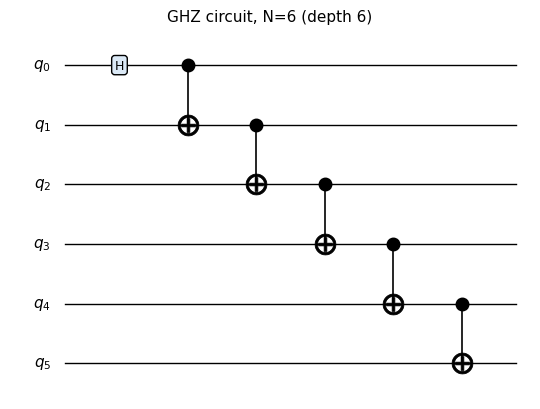

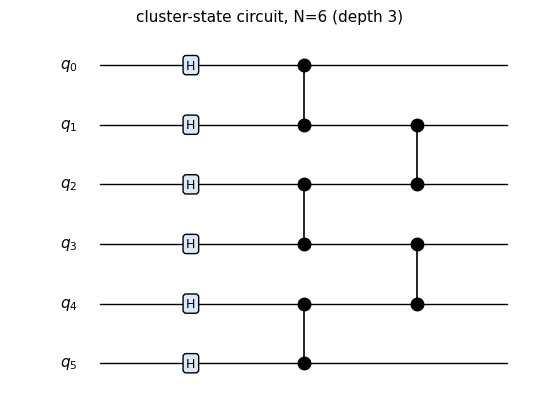

In [17]:
# ==============================================================================
# STEP 6: state-preparation circuits as functions returning labelled gate lists
# ==============================================================================
def bell_circuit():
    """|00> -> (|00> + |11>)/sqrt2."""
    return [("H", (0,), H), ("CNOT", (0, 1), CNOT)]


def ghz_circuit_list(N):
    """|0..0> -> (|0..0> + |1..1>)/sqrt2 :  H on qubit 0 and a cascade of CNOTs."""
    return [("H", (0,), H)] + [("CNOT", (q - 1, q), CNOT) for q in range(1, N)]


def cluster_circuit(N):
    """|0..0> -> 1D cluster state: Hadamards, then CZ on even bonds, then CZ on odd bonds."""
    bonds = [(q, q + 1) for q in range(0, N - 1, 2)] + [(q, q + 1) for q in range(1, N - 1, 2)]
    return [("H", (q,), H) for q in range(N)] + [("CZ", b, CZ) for b in bonds]


N = 6
circuits = {"Bell": (bell_circuit(), 2, bell_state("phi+")),
            "GHZ": (ghz_circuit_list(N), N, ghz_state(N)),
            "cluster": (cluster_circuit(N), N, cluster_state(N))}

for name, (circ, n, reference) in circuits.items():
    psi = apply_gates(zero_state(n), strip_labels(circ))
    infid = 1.0 - float(fidelity_pure(psi, reference))
    _, depth = schedule(circ, n)
    S_half = float(entanglement_entropy(psi, list(range(n // 2))))
    print(f"{name:8s} N={n}: gates {gate_counts(circ)}, depth {depth}, 1 - fidelity with reference = {infid:.1e}, "
          f"half-chain entropy = {S_half:.3f} bit")
    assert abs(infid) < 100 * TOL

psi_cluster = apply_gates(zero_state(N), strip_labels(cluster_circuit(N)))
stab = [float(expect_pauli_string(psi_cluster, {q - 1: "Z", q: "X", q + 1: "Z"})) for q in range(1, N - 1)]
print("cluster-state stabilizers <Z X Z> on sites 1..N-2:", np.round(stab, 12))
assert np.max(np.abs(np.array(stab) - 1.0)) < 100 * TOL

draw_circuit(ghz_circuit_list(N), N, title=f"GHZ circuit, N={N} (depth {N})")
draw_circuit(cluster_circuit(N), N, title=f"cluster-state circuit, N={N} (depth 3)")

All three circuits reproduce the reference states with unit fidelity. The half-chain entanglement entropy is 1 bit in
each case - for the Bell and GHZ states because there are exactly two Schmidt terms ($\lvert0..0\rangle$ and
$\lvert1..1\rangle$), for the cluster state because exactly one CZ gate crosses the cut. All stabilizers of the cluster
state are $+1$. The diagrams show the structural difference: the GHZ circuit is a *sequential* staircase (depth
$N$), the cluster circuit is *parallel* (depth 3 independent of $N$).

> **Physics insight.** The linear depth is forced on *any* nearest-neighbour circuit that prepares GHZ. After $d$ layers
> the operator $Z_0$, propagated back to the input, acts on sites $0,\dots,d$ only, and $Z_{N-1}$ on sites
> $N-1-d,\dots,N-1$ (a light cone). If the two sets do not overlap, $\langle Z_0Z_{N-1}\rangle$ factorises on the product
> input, whereas GHZ has $\langle Z_0Z_{N-1}\rangle-\langle Z_0\rangle\langle Z_{N-1}\rangle=1$; hence $d\ge(N-1)/2$
> (a cascade started in the middle comes within one layer of this bound; long-range gates give depth $\log N$,
> Exercise 4). The cluster state has correlation length of one site and is reachable in constant depth.

## 6. Compiled circuits: `jit`, `vmap`, `scan`

### 6.1 One XLA program per circuit

So far each `apply_gate` call was dispatched separately from Python: for each gate JAX looks up (or compiles) a small
XLA kernel and launches it. The overhead per call is tens of microseconds to milliseconds - irrelevant for $N=20$,
where the contraction itself dominates, but dominant for small registers and thousands of gates.

`jax.jit` removes this overhead: it *traces* the Python function once - the `for` loop in `apply_gates` is unrolled
during tracing - and hands the whole sequence of contractions to the XLA compiler, which produces one fused program.
The rules of the game (notebook 01):

* the **structure** of the circuit - which gate acts on which qubits, the number of gates - is *static*: it is frozen
  into the compiled program (qubit labels define the einsum strings);
* the **numbers** - the input state, rotation angles - are *traced*: they can change from call to call without
  recompilation.

The natural design is therefore a pure function `circuit(params, psi0) -> psi` with the structure written as ordinary
Python. As an example we take a layered parametrised circuit (the type used as a variational ansatz in Chapter 11): each
layer applies $R_y$ and $R_z$ with individual angles to every qubit and then a chain of CZ gates.

In [18]:
# ==============================================================================
# STEP 7: a parametrised layered circuit as a pure function of its angles
# ==============================================================================
def layer_gates(theta_layer, N):
    """One layer as a gate list.  theta_layer has shape (N, 2): angles of Ry and Rz for every qubit."""
    gates = []
    for q in range(N):
        gates += [((q,), ry(theta_layer[q, 0])), ((q,), rz(theta_layer[q, 1]))]
    gates += [((q, q + 1), CZ) for q in range(N - 1)]
    return gates


def layered_circuit(theta, psi):
    """Apply L layers to psi.  theta has shape (L, N, 2).  Pure function: jit-, vmap- and grad-compatible."""
    N = psi.ndim
    for theta_layer in theta:                       # Python loop: unrolled at trace time
        psi = apply_gates(psi, layer_gates(theta_layer, N))
    return psi


# PARAMETERS
N_perf, L_perf = 12, 6                              # register size and number of layers
key = jax.random.PRNGKey(2024)                      # explicit PRNG key: same key -> same angles
theta = jax.random.uniform(key, (L_perf, N_perf, 2), minval=0.0, maxval=2 * jnp.pi)
psi0 = zero_state(N_perf)
n_gates = L_perf * (3 * N_perf - 1)

# --- eager execution: one dispatch per gate (the first call also compiles every small kernel) -------------
layered_circuit(theta, psi0).block_until_ready()
t0 = time.perf_counter()
psi_eager = layered_circuit(theta, psi0).block_until_ready()
t_eager = time.perf_counter() - t0

# --- jit: compile once, then run ---------------------------------------------------------------------------
layered_jit = jax.jit(layered_circuit)
t0 = time.perf_counter()
layered_jit(theta, psi0).block_until_ready()        # first call = trace + compile + run
t_compile = time.perf_counter() - t0
t0 = time.perf_counter()
psi_jit = layered_jit(theta, psi0).block_until_ready()
t_run = time.perf_counter() - t0

err = float(jnp.max(jnp.abs(psi_eager - psi_jit)))
print(f"N={N_perf}, {L_perf} layers, {n_gates} gates")
print(f"   eager (gate by gate)   : {1e3 * t_eager:9.2f} ms")
print(f"   jit, first call        : {1e3 * t_compile:9.2f} ms   (tracing + compilation + run)")
print(f"   jit, subsequent calls  : {1e3 * t_run:9.2f} ms   -> speed-up x{t_eager / t_run:.0f} over eager")
print(f"   |psi_eager - psi_jit|_max = {err:.1e},  norm = {float(jnp.linalg.norm(psi_jit)):.12f}")
assert err < 100 * TOL

N=12, 6 layers, 210 gates
   eager (gate by gate)   :    935.17 ms
   jit, first call        :   8110.05 ms   (tracing + compilation + run)
   jit, subsequent calls  :     20.08 ms   -> speed-up x47 over eager
   |psi_eager - psi_jit|_max = 0.0e+00,  norm = 1.000000000000


The compiled circuit gives the same state (to rounding) and runs much faster than gate-by-gate execution; the price
is a one-off compilation that takes far longer than a single run. Compilation pays off whenever the same circuit
*structure* is executed many times - with different angles (optimisation, parameter sweeps), different input states,
or different random numbers (trajectories). The precise numbers depend on your machine; the pattern does not.
(`block_until_ready()` is essential for timing because JAX dispatches work asynchronously, notebook 01.)

> **JAX practice.** A new compilation is triggered whenever the *shapes* or the *static structure* change: another
> $N$, another number of layers, another qubit pattern. Changing the *values* of `theta` or `psi0` never recompiles.
> If you accidentally pass a qubit index as a traced value, the `int(q)` inside `apply_gate` raises a
> `ConcretizationTypeError` ("The problem arose with the `int` function") - qubits must be Python integers.

### 6.2 Parameter sweeps with `vmap`

Because the circuit is a pure function of its angles, a parameter sweep is one line: `vmap` over the quantity that
changes. Example: a Ramsey-type interferometer on a GHZ state. We prepare the GHZ state, let every qubit precess by
$R_z(\phi)$ and measure the parity $\langle X^{\otimes N}\rangle$. Since
$R_z(\phi)^{\otimes N}(\lvert0..0\rangle+\lvert1..1\rangle) \propto \lvert0..0\rangle+e^{iN\phi}\lvert1..1\rangle$, the prediction is
$\langle X^{\otimes N}\rangle=\cos(N\phi)$: the fringes oscillate $N$ times faster than for a single qubit
($\langle X\rangle=\cos\phi$ for $\lvert+\rangle$). This is the origin of the Heisenberg limit of quantum metrology
([notebook 32](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb), Chapter 10).

N=1: max |signal - cos(N phi)| = 4.4e-16


N=2: max |signal - cos(N phi)| = 6.7e-16


N=6: max |signal - cos(N phi)| = 1.9e-15


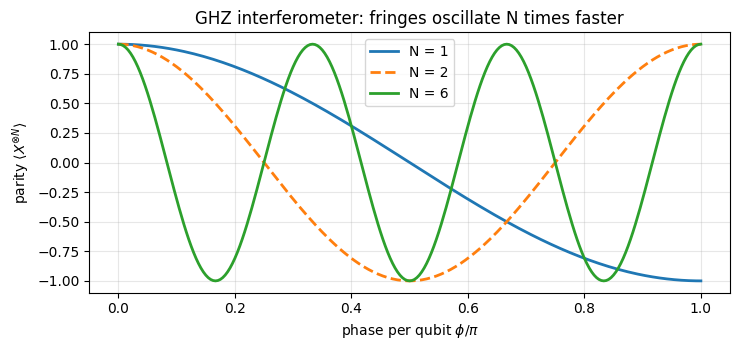

In [19]:
# ==============================================================================
# STEP 8: vmap over a gate angle -- GHZ interference fringes  <X...X>(phi) = cos(N phi)
# ==============================================================================
def ghz_parity_signal(phi, N):
    """<X^(x)N> after the circuit  GHZ preparation -> Rz(phi) on every qubit."""
    gates = strip_labels(ghz_circuit_list(N)) + [((q,), rz(phi)) for q in range(N)]
    psi = apply_gates(zero_state(N), gates)
    return expect_pauli_string(psi, "X" * N)


phis = jnp.linspace(0.0, jnp.pi, 241)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for N_ghz, ls in ((1, "-"), (2, "--"), (6, "-")):
    signal = jax.jit(jax.vmap(partial(ghz_parity_signal, N=N_ghz)))(phis)      # all 241 circuits in one call
    err = float(jnp.max(jnp.abs(signal - jnp.cos(N_ghz * phis))))
    print(f"N={N_ghz}: max |signal - cos(N phi)| = {err:.1e}")
    assert err < 100 * TOL
    ax.plot(phis / jnp.pi, signal, ls, lw=2, label=f"N = {N_ghz}")
ax.set_xlabel(r"phase per qubit $\phi/\pi$")
ax.set_ylabel(r"parity $\langle X^{\otimes N}\rangle$")
ax.set_title("GHZ interferometer: fringes oscillate N times faster")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The simulated fringes coincide with $\cos(N\phi)$ to machine precision. In `partial(ghz_parity_signal, N=N_ghz)`
the register size is a *static* Python integer fixed before `vmap`/`jit` see the function, while `phi` is the
traced, batched argument. (For $N=1$ the "GHZ circuit" is just a Hadamard, preparing $\lvert+\rangle$.)

### 6.3 Deep circuits: `lax.scan` over layers

Unrolling has a cost: a circuit with $L$ identical-structure layers is traced and compiled as $L$ copies of the
layer, so the program handed to XLA grows linearly with $L$ and the compilation time grows at least that fast (the
optimisation passes inside XLA are not linear in the program size). When the layers differ only by their *angles*,
`lax.scan` compiles the layer **once** and loops inside XLA, feeding it one slice `theta[l]` per iteration
(notebook 01):
```python
psi_final, _ = lax.scan(step, psi0, theta)     # step(psi, theta_layer) -> (new_psi, None)
```

In [20]:
# ==============================================================================
# STEP 9: deep circuit -- Python loop unrolled under jit  vs  lax.scan over the layers
# ==============================================================================
def layered_circuit_scan(theta, psi):
    """Same circuit as `layered_circuit`, but the loop over layers is a lax.scan (compiled once)."""
    N = psi.ndim

    def step(psi, theta_layer):
        return apply_gates(psi, layer_gates(theta_layer, N)), None

    psi, _ = lax.scan(step, psi, theta)
    return psi


N_deep, L_deep = 10, 40
theta_deep = jax.random.uniform(jax.random.PRNGKey(7), (L_deep, N_deep, 2), maxval=2 * jnp.pi)
psi0_deep = zero_state(N_deep)

timings = {}
for name, fn in (("unrolled", jax.jit(layered_circuit)), ("scan", jax.jit(layered_circuit_scan))):
    t0 = time.perf_counter()
    out = fn(theta_deep, psi0_deep).block_until_ready()
    t_first = time.perf_counter() - t0
    t0 = time.perf_counter()
    out = fn(theta_deep, psi0_deep).block_until_ready()
    timings[name] = (t_first, time.perf_counter() - t0, out)
    print(f"{name:9s}: first call {t_first:6.2f} s (compile),  run {1e3 * timings[name][1]:7.2f} ms")

err = float(jnp.max(jnp.abs(timings["unrolled"][2] - timings["scan"][2])))
print(f"|psi_unrolled - psi_scan|_max = {err:.1e}   ({L_deep} layers, {L_deep * (3 * N_deep - 1)} gates, N={N_deep})")
assert err < 100 * TOL

unrolled : first call  29.99 s (compile),  run   34.53 ms


scan     : first call   1.57 s (compile),  run   97.44 ms


|psi_unrolled - psi_scan|_max = 0.0e+00   (40 layers, 1160 gates, N=10)


Both versions produce the same state. The `scan` version compiles far faster - by more than an order of magnitude -
because XLA sees a single layer instead of 40 copies; the run times are of the same order. Rule of
thumb: **unroll short circuits, scan long repetitive ones** - Trotter evolutions with thousands of identical steps
(Section 9) are always scanned.

## 7. Circuit identities for compilation

Circuit identities are the "algebra rules" used to rewrite (compile) a circuit into the native gates of a device. The
most useful ones:

| identity | meaning |
|---|---|
| $HZH = X$, $HXH=Z$, $HYH=-Y$ | Hadamard exchanges the roles of $x$ and $z$ |
| $SXS^\dagger = Y$ | $S$ rotates $x$ into $y$ |
| $(1\otimes H)\,\mathrm{CZ}\,(1\otimes H) = \mathrm{CNOT}$ | CNOT from the symmetric CZ: the target is the qubit dressed with $H$ |
| $(H\otimes H)\,\mathrm{CNOT}_{0\to1}\,(H\otimes H) = \mathrm{CNOT}_{1\to0}$ | control and target are exchanged in the $X$ basis |
| $\mathrm{CNOT}_{0\to1}\mathrm{CNOT}_{1\to0}\mathrm{CNOT}_{0\to1} = \mathrm{SWAP}$ | SWAP from three CNOTs |
| $\mathrm{CNOT}\,(1\otimes R_z(\theta))\,\mathrm{CNOT} = R_{zz}(\theta)$ | Ising gate from CNOTs and a rotation |
| $(H\otimes H)R_{zz}(\theta)(H\otimes H) = R_{xx}(\theta)$ | basis change $z\to x$ |
| $(1\otimes1\otimes H)\,\mathrm{CCZ}\,(1\otimes1\otimes H) = \mathrm{Toffoli}$ | same trick as CZ $\to$ CNOT |

Two of them are derived below; the rest follow by the same manipulations.

*CNOT from CZ.* Write $\mathrm{CZ} = P_0\otimes1+P_1\otimes Z$ [Eq. (6)]. Conjugating the second qubit with $H$ gives
$P_0\otimes HH + P_1\otimes HZH = P_0\otimes 1+P_1\otimes X = \mathrm{CNOT}$, using $H^2=1$ and $HZH=X$.

*$R_{zz}$ from CNOTs.* CNOT maps the basis state $\lvert a,b\rangle$ to $\lvert a,a\oplus b\rangle$. Then $R_z(\theta)$ on the
second qubit multiplies by $e^{-i\theta(-1)^{a\oplus b}/2}$, and the second CNOT restores $\lvert a,b\rangle$. The net
effect is the phase $e^{-i\theta(-1)^{a}(-1)^{b}/2}$, i.e. $e^{-i\theta Z\otimes Z/2}$: the CNOT *computes the parity*
of the two bits into the target, the rotation imprints a parity-dependent phase, the second CNOT uncomputes.

**From formula to code.** To verify an identity between circuits we need the *unitary matrix of a circuit*. We obtain
it without any Kronecker product from the matrix-free action: column $j$ of $U$ is the circuit applied to the basis
state $\lvert j\rangle$. `jax.vmap` applies the circuit to all $2^N$ basis tensors at once - the same trick as
`dense_hamiltonian` in notebook 05. (Validation tool for small $N$ only: the result has $4^N$ entries.)

In [21]:
# ==============================================================================
# STEP 10: dense unitary of a circuit from its matrix-free action on all basis states (vmap)
# ==============================================================================
def circuit_unitary(gates, N):
    """2^N x 2^N matrix of a gate list:  U[:, j] = circuit |j>.   VALIDATION ONLY (4^N numbers)."""
    basis = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)        # basis[j] = |j> as a rank-N tensor
    columns = jax.jit(jax.vmap(lambda e: apply_gates(e, gates).reshape(-1)))(basis)   # row j of `columns` = U|j>
    return columns.T


th = 0.913                                   # a generic angle for the parametrised identities
identities = [
    ("H Z H = X",                    [((0,), H), ((0,), Z), ((0,), H)],                        X, 1),
    ("H X H = Z",                    [((0,), H), ((0,), X), ((0,), H)],                        Z, 1),
    ("H Y H = -Y",                   [((0,), H), ((0,), Y), ((0,), H)],                        -Y, 1),
    ("S X S^dag = Y",                [((0,), SDG), ((0,), X), ((0,), S)],                      Y, 1),
    ("CNOT = (1xH) CZ (1xH)",        [((1,), H), ((0, 1), CZ), ((1,), H)],                     CNOT, 2),
    ("reversed CNOT = HH CNOT HH",   [((0,), H), ((1,), H), ((0, 1), CNOT), ((0,), H), ((1,), H)],
                                     circuit_unitary([((1, 0), CNOT)], 2), 2),
    ("SWAP = 3 CNOTs",               [((0, 1), CNOT), ((1, 0), CNOT), ((0, 1), CNOT)],         SWAP, 2),
    ("Rzz = CNOT (1xRz) CNOT",       [((0, 1), CNOT), ((1,), rz(th)), ((0, 1), CNOT)],         rzz(th), 2),
    ("Rxx = HH Rzz HH",              [((0,), H), ((1,), H), ((0, 1), rzz(th)), ((0,), H), ((1,), H)], rxx(th), 2),
    ("Ryy = Rx Rx Rzz Rx^dag Rx^dag", [((0,), rx(-jnp.pi / 2)), ((1,), rx(-jnp.pi / 2)), ((0, 1), rzz(th)),
                                      ((0,), rx(jnp.pi / 2)), ((1,), rx(jnp.pi / 2))],         ryy(th), 2),
    ("Toffoli = H CCZ H",            [((2,), H), ((0, 1, 2), CCZ), ((2,), H)],                 TOFFOLI, 3),
]

print(f"{'identity':34s} {'|U_circ - U_target|_max':>24s} {'Delta (phase-blind)':>22s}")
for text, gates, target, n in identities:
    U_circ = circuit_unitary(gates, n)
    err = float(jnp.max(jnp.abs(U_circ - target)))
    print(f"{text:34s} {err:24.1e} {gate_distance(U_circ, target):22.1e}")
    assert err < 100 * TOL

identity                            |U_circ - U_target|_max    Delta (phase-blind)
H Z H = X                                           2.2e-16                2.2e-16
H X H = Z                                           2.2e-16                2.2e-16
H Y H = -Y                                          2.2e-16                2.2e-16


S X S^dag = Y                                       0.0e+00                0.0e+00


CNOT = (1xH) CZ (1xH)                               2.2e-16                2.2e-16


reversed CNOT = HH CNOT HH                          3.3e-16                3.3e-16


SWAP = 3 CNOTs                                      0.0e+00                0.0e+00
Rzz = CNOT (1xRz) CNOT                              0.0e+00                0.0e+00


Rxx = HH Rzz HH                                     3.3e-16                4.4e-16


Ryy = Rx Rx Rzz Rx^dag Rx^dag                       1.1e-16                1.1e-16


Toffoli = H CCZ H                                   2.2e-16                1.1e-16


Every identity of the table holds *exactly* (not only up to a phase): the entry-wise error is at the level of
rounding. The gate lists are in time order: for $SXS^\dagger$ the list is `[SDG, X, S]` because the rightmost operator of
the formula acts first (the pitfall of Section 5.1). The $R_{yy}$ line uses
$R_x(\tfrac\pi2)\,Z\,R_x(-\tfrac\pi2) = -Y$: the two minus signs cancel in $Y\otimes Y$.

One further identity connects gates with the Heisenberg interaction of notebook 03. Because
$X\otimes X$, $Y\otimes Y$ and $Z\otimes Z$ commute with each other, the evolution under the exchange interaction
factorises *exactly*, and using $X\otimes X+Y\otimes Y+Z\otimes Z = 2\,\mathrm{SWAP}-1$ together with
$\mathrm{SWAP}^2=1$ and Eq. (2):

$$ e^{-i\tau(XX+YY+ZZ)} = R_{xx}(2\tau)R_{yy}(2\tau)R_{zz}(2\tau) = e^{i\tau}\big(\cos 2\tau - i\sin2\tau\;\mathrm{SWAP}\big). $$

At $\tau=\pi/4$ this is $-i\,e^{i\pi/4}\,\mathrm{SWAP} = e^{-i\pi/4}\,\mathrm{SWAP}$: letting two spins interact via
Heisenberg exchange for the right time *swaps their states*, up to a global phase. Half of that time,
$\tau=\pi/8$, gives $e^{i\pi/8}(\cos\frac\pi4 - i\sin\frac\pi4\,\mathrm{SWAP})$, which is the entangling
$\sqrt{\mathrm{SWAP}}$ gate again up to a global phase (its square is $e^{-i\pi/4}\mathrm{SWAP}$, not
$\mathrm{SWAP}$ on the nose) - the native two-qubit gate of electron-spin qubits in quantum dots.

In [22]:
# ==============================================================================
# CHECKPOINT: Heisenberg exchange = Rxx Ryy Rzz = SWAP at tau = pi/4 (up to a global phase)
# ==============================================================================
tau = 0.37
U_exchange = expm(-1j * tau * (XX + YY + ZZ))
U_product = circuit_unitary([((0, 1), rxx(2 * tau)), ((0, 1), ryy(2 * tau)), ((0, 1), rzz(2 * tau))], 2)
U_formula = jnp.exp(1j * tau) * (jnp.cos(2 * tau) * jnp.eye(4) - 1j * jnp.sin(2 * tau) * SWAP)
err1 = float(jnp.max(jnp.abs(U_exchange - U_product)))
err2 = float(jnp.max(jnp.abs(U_exchange - U_formula)))
d_swap = gate_distance(expm(-1j * (jnp.pi / 4) * (XX + YY + ZZ)), SWAP)
print(f"|exp(-i tau (XX+YY+ZZ)) - Rxx Ryy Rzz|_max = {err1:.1e}")
print(f"|exp(-i tau (XX+YY+ZZ)) - closed form  |_max = {err2:.1e}")
print(f"Delta( exchange for tau = pi/4 , SWAP ) = {d_swap:.1e}")
assert max(err1, err2, d_swap) < 100 * TOL

|exp(-i tau (XX+YY+ZZ)) - Rxx Ryy Rzz|_max = 1.2e-16
|exp(-i tau (XX+YY+ZZ)) - closed form  |_max = 1.2e-16
Delta( exchange for tau = pi/4 , SWAP ) = 0.0e+00


## 8. A remark on universality

A gate set is called **universal** if every unitary on $N$ qubits can be
approximated to arbitrary accuracy by a circuit built from it. We quote three classic results (proofs: Nielsen &
Chuang, Ch. 4; Barenco *et al.* 1995):

1. *All single-qubit gates + CNOT* are exactly universal: any $2^N\times2^N$ unitary can be decomposed into them
   (a generic unitary has $4^N$ real parameters, so it needs at least of order $4^N$ gates; universality says
   nothing about efficiency).
2. The *finite* set $\{H, T, \mathrm{CNOT}\}$ is universal in the approximate sense: its circuits form a dense subset
   of the unitary group, so any target can be reached to accuracy $\varepsilon$. The **Solovay-Kitaev theorem**
   bounds the price: $O(\log^c(1/\varepsilon))$ gates per single-qubit target. The algorithm of Dawson and Nielsen
   (2006) achieves $c\approx3.97$; the variant of Kitaev, Shen and Vyalyi discussed in the same paper reaches
   $c=3+\delta$ for any $\delta>0$. The
   counting bound of the next paragraph shows $c\ge1$ is unavoidable; $c=1$ is in fact *reached*, but not by
   Solovay-Kitaev - number-theoretic synthesis algorithms specific to the Clifford$+T$ gate set do it
   (Ross and Selinger 2016).
3. $H$, $S$ and CNOT generate the **Clifford group**, which is *not* universal: circuits built from these gates
   alone, acting on a computational-basis input and read out in the computational basis, can be simulated efficiently
   on a classical computer (Gottesman-Knill theorem, Gottesman 1998). The non-Clifford $T$ gate is the "magic"
   ingredient; we return to it in [notebook 10](10_random_unitaries_and_random_circuits.ipynb) and in
   [notebook 27](../ch09_entanglement_and_complexity/27_stabilizer_renyi_entropy.ipynb) (Chapter 9).

**A numerical experiment for statement 2.** Separately, $H$ and $T$ are rotations by *rational* multiples of $\pi$
($H$ by $\pi$ about $(\hat x+\hat z)/\sqrt2$, $T$ by $\pi/4$ about $\hat z$), so each of them alone generates only a
finite set. Density comes from their *product*: $HT$ is a rotation by an angle $\theta$ that is an irrational
multiple of $\pi$. Indeed $(2\cos\frac\theta2)^2 = 1-1/\sqrt2$ (checked in the cell below, $\theta=0.8256\,\pi$),
which is not an algebraic integer (it solves $y^2-2y+\frac12=0$), whereas $2\cos(r\pi)=e^{ir\pi}+e^{-ir\pi}$, and
with it its square, is one for every rational $r$. The powers of $HT$ therefore come arbitrarily close to every
rotation about the $HT$ axis, and combining that axis with a second one fills the whole group (Nielsen & Chuang,
Ch. 4). Enumerating all $2^\ell$
words of length $\ell$ is wasteful, because most words coincide ($H^2=1$, $T^8=1$, $T^2=S$ is a Clifford gate, ...).
Matsumoto and Amano (2008) proved that every product of $H$ and $T$ gates can be written *uniquely*, up to a global
phase, in the normal form

$$ U = (T\ \text{or}\ 1)\;\underbrace{(HT\ \text{or}\ SHT)\cdots(HT\ \text{or}\ SHT)}_{m\ \text{syllables}}\;C,\qquad C\in\text{24 single-qubit Clifford gates}, $$

which contains $m$ or $m+1$ $T$ gates. (The 24 Clifford gates - all products of $H$ and $S$ - are constructed in
[notebook 10](10_random_unitaries_and_random_circuits.ipynb); here we take them from the engine.) There are
$2^m$ syllable strings, so the number of distinct gates grows like $2^{\text{T-count}}$ - and we can enumerate them
all up to $m=14$. For each $m$ we ask how well the best gate approximates a target rotation, here
$R_z(0.3)$, $R_y(1.0)$ and $R_x(\sqrt2)$, in the phase-blind distance of Eq. (4).

**From formula to code.** If `words` has shape $(W,2,2)$, appending one of the two syllables to every word is the
batched product `einsum("wij,sjk->wsik", words, syllables)` reshaped to $(2W,2,2)$. The trailing Clifford and the
target are absorbed into 24 small matrices $M_c = C_c\,V_{\rm target}^\dagger$, so that the overlap
$\mathrm{Tr}(V^\dagger_{\rm target}\,W C_c)=\mathrm{Tr}(M_c W)$ is one more einsum, `"cij,wji->cw"`, without ever
storing the $24\times W$ products.

rotation angle of H   = 1.000000 pi
rotation angle of T   = 0.250000 pi
rotation angle of H T = 0.825557 pi
HT: (2 cos(angle/2))^2 = 0.292893218813452,  1 - 1/sqrt2 = 0.292893218813453



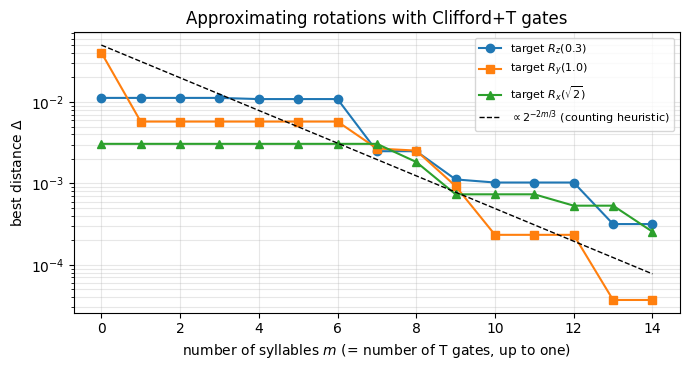

target $R_z(0.3)$        : best Delta = 1.12e-02 (Clifford only), 2.49e-03 (m<=7), 3.17e-04 (m<=14)
target $R_y(1.0)$        : best Delta = 4.05e-02 (Clifford only), 2.68e-03 (m<=7), 3.71e-05 (m<=14)
target $R_x(\sqrt{2})$   : best Delta = 3.06e-03 (Clifford only), 3.06e-03 (m<=7), 2.56e-04 (m<=14)


In [23]:
# ==============================================================================
# STEP 11: best Clifford+T approximation of a given rotation (enumeration of normal forms)
# ==============================================================================
def rotation_angle(U):
    """Rotation angle of a 2x2 unitary: remove the phase (det V = 1), then Tr V = 2 cos(angle/2)."""
    V = U / jnp.sqrt(jnp.linalg.det(U))
    return float(2 * jnp.arccos(jnp.clip(jnp.abs(jnp.trace(V)) / 2, 0.0, 1.0)))


for name, U in (("H", H), ("T", T), ("H T", H @ T)):
    print(f"rotation angle of {name:3s} = {rotation_angle(U) / np.pi:.6f} pi")
x2 = (2 * np.cos(rotation_angle(H @ T) / 2)) ** 2
print(f"HT: (2 cos(angle/2))^2 = {x2:.15f},  1 - 1/sqrt2 = {1 - 1 / np.sqrt(2):.15f}\n")
assert abs(x2 - (1 - 1 / np.sqrt(2))) < 100 * TOL

M_MAX = 14                                                             # syllables; 2^14 = 16384 strings
targets = {r"$R_z(0.3)$": rz(0.3), r"$R_y(1.0)$": ry(1.0), r"$R_x(\sqrt{2})$": rx(jnp.sqrt(2.0))}
cliffords = single_qubit_cliffords()                                   # (24, 2, 2), from the engine
syllables = jnp.stack([H @ T, S @ H @ T])                              # the two syllables HT and SHT


@jax.jit
def append_syllable(words):
    """All words with one more syllable: (W,2,2) -> (2W,2,2)."""
    return jnp.einsum("wij,sjk->wsik", words, syllables).reshape(-1, 2, 2)


@jax.jit
def best_distance(words, target):
    """min of Delta(target, P W C) over words W, Cliffords C and prefix P in {1, T}."""
    both = jnp.concatenate([words, jnp.einsum("ij,wjk->wik", T, words)])          # optional leading T
    M_c = jnp.einsum("cij,jk->cik", cliffords, target.conj().T)                   # C_c V^dag
    overlaps = jnp.abs(jnp.einsum("cij,wji->cw", M_c, both)) / 2                   # |Tr(V^dag W C_c)| / 2
    return 1.0 - jnp.max(overlaps)


words = I2[None]                                                       # m = 0: the empty syllable string
best = {name: [] for name in targets}
for m in range(M_MAX + 1):
    if m > 0:
        words = append_syllable(words)
    for name, target in targets.items():
        previous = best[name][-1] if best[name] else 1.0
        best[name].append(min(previous, float(best_distance(words, target))))     # best gate with <= m syllables

fig, ax = plt.subplots(figsize=(7, 3.8))
ms = np.arange(M_MAX + 1)
for (name, vals), marker in zip(best.items(), ("o", "s", "^")):
    ax.semilogy(ms, np.maximum(vals, 1e-16), marker=marker, label="target " + name)
ax.semilogy(ms, 0.05 * 2.0 ** (-2 * ms / 3), "k--", lw=1, label=r"$\propto 2^{-2m/3}$ (counting heuristic)")
ax.set_xlabel(r"number of syllables $m$ (= number of T gates, up to one)")
ax.set_ylabel(r"best distance $\Delta$")
ax.set_title("Approximating rotations with Clifford+T gates")
ax.grid(alpha=0.3, which="both")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
for name, vals in best.items():
    print(f"target {name:18s}: best Delta = {vals[0]:.2e} (Clifford only), {vals[7]:.2e} (m<=7), {vals[-1]:.2e} (m<=14)")

With Clifford gates alone ($m=0$) one can only reach the nearest of 24 rotations. Every additional $T$ gate doubles the
number of available gates, and the best distance falls - in steps, and for the first few $m$ hardly at all (there are
too few gates for statistics), but for $m\gtrsim6$ roughly parallel to the dashed line.

The dashed line is a **counting heuristic**. The gates reachable with $m$
syllables are $\sim2^m$ points scattered over the three-dimensional group of rotations, so if they were spread evenly
their typical spacing would be $\theta\propto(2^{-m})^{1/3}=2^{-m/3}$ in rotation angle. Two gates that differ by a
small rotation $\theta$ have $\Delta = 1-\lvert\cos\frac\theta2\rvert\approx\theta^2/8$ [insert $V=UR_{\mathbf n}(\theta)$
in Eq. (4) and use $\mathrm{Tr}\,R_{\mathbf n}(\theta)=2\cos\frac\theta2$], hence $\Delta\propto2^{-2m/3}$. Reading it
the other way round: one extra decimal digit of accuracy in $\theta$ means $\theta\to\theta/10$, which costs
$3\log_2 10\approx10$ more $T$ gates. The heuristic assumes an even spread, which is why the measured curves scatter
around the line by a factor of a few rather than following it point by point.

The rigorous statement has the same scaling: for $z$-rotations, Ross and Selinger (2016) give an algorithm that finds
the shortest ancilla-free Clifford$+T$ circuit within $\varepsilon$ (given a factoring oracle; without one it is
near-optimal under a number-theoretic hypothesis), and in the typical case its $T$-count is
$3\log_2(1/\varepsilon)+O(\log\log(1/\varepsilon))$, i.e. again about ten $T$ gates per decimal digit. Our brute-force search costs $2^m$; such number-theoretic synthesis
algorithms find the sequences in $\mathrm{polylog}(1/\varepsilon)$ time.
In this course we will not compile to $\{H,T\}$: a simulator can apply any $R_{\mathbf n}(\theta)$
directly. But the experiment explains why fault-tolerant quantum computers, whose protected gate set is finite, count
their cost in "number of $T$ gates".

## 9. A Trotter step is a circuit

### 9.1 From the Hamiltonian to gates

We return to the transverse-field Ising model (TFIM) of notebooks 03-05 on an open chain (Pauli convention),

$$ H_{\rm TFIM} = J\sum_{q=0}^{N-2} Z_qZ_{q+1} + h\sum_{q=0}^{N-1}X_q \equiv H_{zz}+H_x . $$

The first-order Trotter formula (notebook 04) approximates one time step by
$e^{-iH_{\rm TFIM}\,dt}\approx e^{-iH_x dt}e^{-iH_{zz}dt}$ with an error $O(dt^2)$ per step. All terms inside $H_{zz}$ commute
with each other, and so do all terms of $H_x$, hence each factor is *exactly* a product of gates we know:

$$ e^{-iH_{zz}dt} = \prod_q e^{-iJdt\,Z_qZ_{q+1}} = \prod_q R_{zz}^{(q,q+1)}(2J\,dt),\qquad
   e^{-iH_xdt} = \prod_q R_x^{(q)}(2h\,dt). \tag{8}$$

(The factor 2 comes from the $\theta/2$ in the definition of the rotation gates.) The second-order (Strang)
splitting $e^{-iH_x dt/2}e^{-iH_{zz}dt}e^{-iH_xdt/2}$ has error $O(dt^3)$ per step and costs only one extra layer of
single-qubit gates. This is **digital quantum simulation**: the time evolution of a spin model becomes a circuit of
$R_{zz}$ and $R_x$ gates that a quantum processor can run (Lloyd 1996). The "Trotter gates" `exp(-i h dt)` that we
applied by einsum in notebook 05 were quantum gates all along.

We order the $R_{zz}$ gates as *even bonds, then odd bonds*. They commute, so the order does not change the unitary -
but it changes the depth: two layers instead of a staircase of $N-1$.

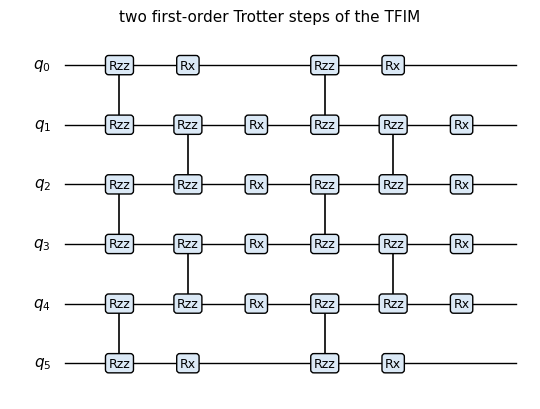

|U(Rzz/Rx circuit) - U(tebd_gates)|_max = 1.5e-15
one step: gates {2: 5, 1: 6}, depth 3


In [24]:
# ==============================================================================
# STEP 12: Trotter step of the TFIM as a labelled circuit
# ==============================================================================
def tfim_trotter_circuit(N, J, h, dt, order=1):
    """One Trotter step of H = J sum Z_q Z_{q+1} + h sum X_q as a circuit of Rzz and Rx gates.

    MATH   order 1:  prod_q Rx(2 h dt) * prod_bonds Rzz(2 J dt)                       [Eq. (8)]
           order 2:  prod_q Rx(h dt) * prod_bonds Rzz(2 J dt) * prod_q Rx(h dt)      (Strang splitting)
    dt may be a traced scalar.  Bonds are ordered even-then-odd => the Rzz part has depth 2.
    """
    bonds = [(q, q + 1) for q in range(0, N - 1, 2)] + [(q, q + 1) for q in range(1, N - 1, 2)]
    zz_layer = [("Rzz", b, rzz(2 * J * dt)) for b in bonds]
    if order == 1:
        return zz_layer + [("Rx", (q,), rx(2 * h * dt)) for q in range(N)]
    half_x = [("Rx", (q,), rx(h * dt)) for q in range(N)]
    return half_x + zz_layer + half_x


# PARAMETERS
N_tr, J_tr, h_tr, dt_tr = 6, 1.0, 1.0, 0.1
step1 = tfim_trotter_circuit(N_tr, J_tr, h_tr, dt_tr, order=1)
draw_circuit(step1 + step1, N_tr, title="two first-order Trotter steps of the TFIM")

# CHECKPOINT: identical (as a unitary) to the engine's TEBD step of notebook 05, built from exp(-i h_k dt)
terms = heisenberg_terms(N_tr, Jxx=0.0, Jyy=0.0, Jzz=J_tr, hx=h_tr)               # list of local terms of the TFIM
U_circ = circuit_unitary(strip_labels(step1), N_tr)
U_tebd = circuit_unitary(tebd_gates(terms, dt_tr, order=1), N_tr)
err = float(jnp.max(jnp.abs(U_circ - U_tebd)))
print(f"|U(Rzz/Rx circuit) - U(tebd_gates)|_max = {err:.1e}")
assert err < 100 * TOL
print(f"one step: gates {gate_counts(step1)}, depth {schedule(step1, N_tr)[1]}")

The circuit built from named gates is the same unitary as the engine's TEBD step (which exponentiates each local term
numerically) - the two languages agree. One step has depth 3 for any $N$: two layers of $R_{zz}$ and one of $R_x$.

### 9.2 Running the digital simulation and checking it

We repeat the quench of notebooks 04/05 - start from $\lvert0\dots0\rangle$ (all spins up), evolve with the TFIM - now as a
circuit of `n_steps` identical steps, folded with `lax.scan`, recording the magnetisation of the central spin after
every step. The reference is the dense exact evolution of notebook 04 (one diagonalisation of the $256\times256$
Hamiltonian matrix, affordable at $N=8$). Then we measure the
error of the final state against the step size for both Trotter orders; the expected *global* errors are $O(dt)$ and
$O(dt^2)$ in the state, i.e. slopes 2 and 4 for the infidelity $1-F$ on a log-log plot.

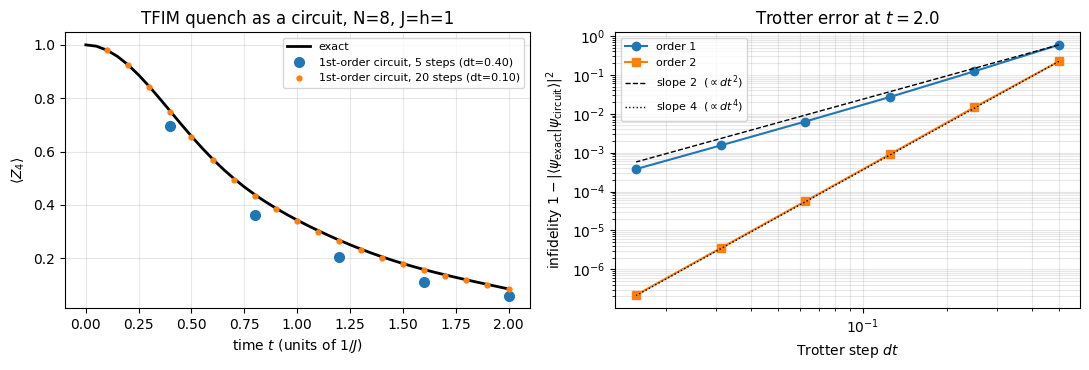

order 1: infidelity 5.89e-01 (dt=0.50) -> 3.78e-04 (dt=0.0156); fitted slope = 2.05
order 2: infidelity 2.21e-01 (dt=0.50) -> 2.19e-07 (dt=0.0156); fitted slope = 4.00


In [25]:
# ==============================================================================
# STEP 13: digital quantum simulation of a TFIM quench (scan over Trotter steps) + error scaling
# ==============================================================================
# PARAMETERS
N_q, J_q, h_q = 8, 1.0, 1.0            # chain length, Ising coupling, transverse field
t_final = 2.0                           # total evolution time
q_mid = N_q // 2                        # we monitor <Z> of this spin

terms_q = heisenberg_terms(N_q, Jxx=0.0, Jyy=0.0, Jzz=J_q, hx=h_q)
psi_start = zero_state(N_q)
z_mid = lambda psi: jnp.real(jnp.trace(rdm(psi, [q_mid]) @ Z))          # observable <Z_mid>


@partial(jax.jit, static_argnames=("n_steps", "order"))
def run_trotter(psi, n_steps, order):
    """n_steps Trotter steps of size t_final/n_steps; returns (final state, <Z_mid> after every step)."""
    gates = strip_labels(tfim_trotter_circuit(N_q, J_q, h_q, t_final / n_steps, order))

    def step(psi, _):
        psi = apply_gates(psi, gates)
        return psi, z_mid(psi)

    return lax.scan(step, psi, None, length=n_steps)


@partial(jax.jit, static_argnames="order")
def trotter_final_state(psi, n_steps, order):
    """Final state only.  n_steps is TRACED (lax.fori_loop accepts a traced bound): one compilation for all n_steps."""
    gates = strip_labels(tfim_trotter_circuit(N_q, J_q, h_q, t_final / n_steps, order))
    return lax.fori_loop(0, n_steps, lambda i, p: apply_gates(p, gates), psi)


# exact reference (VALIDATION ONLY): ONE dense diagonalisation H = V w V^dag serves all times
w_q, V_q = jnp.linalg.eigh(dense_hamiltonian(terms_q, N_q))
coeff = V_q.conj().T @ psi_start.reshape(-1)                                       # <eigenvector | psi_0>
exact_state = lambda t: ((V_q * jnp.exp(-1j * w_q * t)) @ coeff).reshape((2,) * N_q)
times_ref = jnp.linspace(0.0, t_final, 41)
z_ref = jax.vmap(lambda t: z_mid(exact_state(t)))(times_ref)
psi_exact = exact_state(t_final)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(times_ref, z_ref, "k-", lw=2, label="exact")
for n_steps, marker in ((5, "o"), (20, ".")):
    _, z_trot = run_trotter(psi_start, n_steps, 1)
    axes[0].plot(np.arange(1, n_steps + 1) * t_final / n_steps, z_trot, marker, ms=7,
                 label=f"1st-order circuit, {n_steps} steps (dt={t_final / n_steps:.2f})")
axes[0].set_xlabel(r"time $t$ (units of $1/J$)")
axes[0].set_ylabel(rf"$\langle Z_{{{q_mid}}}\rangle$")
axes[0].set_title(f"TFIM quench as a circuit, N={N_q}, J=h=1")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

steps_list = np.array([4, 8, 16, 32, 64, 128])
infid = {1: [], 2: []}
for order in (1, 2):
    for n_steps in steps_list:
        psi_T = trotter_final_state(psi_start, int(n_steps), order)
        infid[order].append(1.0 - float(fidelity_pure(psi_T, psi_exact)))
dts = t_final / steps_list
for order, marker in ((1, "o"), (2, "s")):
    axes[1].loglog(dts, infid[order], marker, ls="-", label=f"order {order}")
axes[1].loglog(dts, infid[1][0] * (dts / dts[0]) ** 2, "k--", lw=1, label=r"slope 2  ($\propto dt^2$)")
axes[1].loglog(dts, infid[2][0] * (dts / dts[0]) ** 4, "k:", lw=1, label=r"slope 4  ($\propto dt^4$)")
axes[1].set_xlabel(r"Trotter step $dt$")
axes[1].set_ylabel(r"infidelity $1-|\langle\psi_{\rm exact}|\psi_{\rm circuit}\rangle|^2$")
axes[1].set_title(rf"Trotter error at $t={t_final}$")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

for order in (1, 2):
    slope = np.polyfit(np.log(dts[2:]), np.log(np.maximum(infid[order][2:], 1e-300)), 1)[0]
    print(f"order {order}: infidelity {infid[order][0]:.2e} (dt={dts[0]:.2f}) -> {infid[order][-1]:.2e} "
          f"(dt={dts[-1]:.4f}); fitted slope = {slope:.2f}")
    assert abs(slope - 2 * order) < 0.2                # slopes 2 and 4; swapping the orders would fail by 2

Left: already 20 first-order steps follow the exact magnetisation closely, while 5 steps ($dt=0.4$) show visible
deviations. Right: the infidelity falls with slopes close to 2 and 4, as expected from state errors $O(dt)$ and
$O(dt^2)$ (the infidelity is quadratic in the state error). A detailed study of Trotter errors is the subject of
[notebook 12](../ch05_ground_states_and_unitary_dynamics/12_tebd_trotter_suzuki.ipynb) (Chapter 5).

### 9.3 Gate counting for hardware

A device whose native entangling gate is CNOT implements each $R_{zz}$ via the identity
$R_{zz}(\theta)=\mathrm{CNOT}\,(1\otimes R_z(\theta))\,\mathrm{CNOT}$ of Section 7. We "compile" the Trotter step by
rewriting the list - circuits are data, so a compiler pass is a list comprehension - check that the unitary is
unchanged, and count.

|U(compiled) - U(original)|_max = 0.0e+00


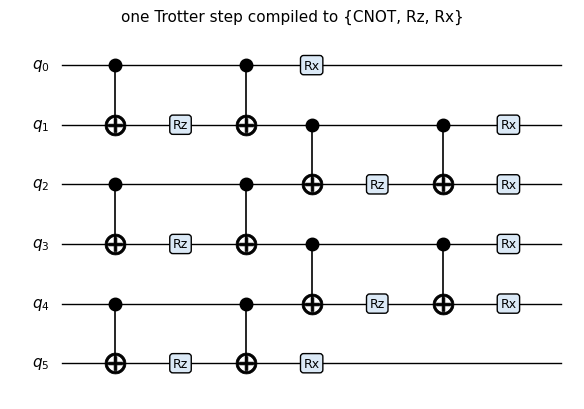


   N   native Rzz: 2q gates  depth   CNOT-compiled: CNOTs  depth
   4                      3      3                      6      7
   8                      7      3                     14      7
  16                     15      3                     30      7


  32                     31      3                     62      7


  64                     63      3                    126      7


In [26]:
# ==============================================================================
# STEP 14: compile Rzz -> CNOT Rz CNOT, verify, and count gates / depth versus N
# ==============================================================================
def compile_rzz_to_cnot(circuit, angle):
    """Replace every ('Rzz', (a,b), .) by CNOT(a,b) Rz_b(angle) CNOT(a,b).  `angle` = rotation angle of the Rzz gates."""
    out = []
    for label, qubits, U in circuit:
        if label == "Rzz":
            a, b = qubits
            out += [("CNOT", (a, b), CNOT), ("Rz", (b,), rz(angle)), ("CNOT", (a, b), CNOT)]
        else:
            out.append((label, qubits, U))
    return out


compiled = compile_rzz_to_cnot(step1, 2 * J_tr * dt_tr)
err = float(jnp.max(jnp.abs(circuit_unitary(strip_labels(compiled), N_tr) - U_circ)))
print(f"|U(compiled) - U(original)|_max = {err:.1e}")
assert err < 100 * TOL
draw_circuit(compiled, N_tr, title="one Trotter step compiled to {CNOT, Rz, Rx}")

print(f"\n{'N':>4s} {'native Rzz: 2q gates':>22s} {'depth':>6s} {'CNOT-compiled: CNOTs':>22s} {'depth':>6s}")
for n in (4, 8, 16, 32, 64):
    native = tfim_trotter_circuit(n, 1.0, 1.0, 0.1)
    comp = compile_rzz_to_cnot(native, 0.2)
    print(f"{n:4d} {gate_counts(native)[2]:22d} {schedule(native, n)[1]:6d} {gate_counts(comp)[2]:22d} {schedule(comp, n)[1]:6d}")

The compiled circuit is the same unitary. Per Trotter step the number of two-qubit gates grows linearly with $N$
($N-1$ native $R_{zz}$ gates, or $2(N-1)$ CNOTs), while the **depth is independent of $N$** (3 natively, 7 after
compilation): a quantum processor executes all bonds of a layer in parallel. A simulation up to time $t$ with step
$dt$ therefore needs depth $\propto t/dt$ and $\propto N\,t/dt$ two-qubit gates. On a *classical* simulator nothing is
parallel in that sense: each gate costs $O(2^N)$, the full evolution $O(N\,2^N\,t/dt)$ - the exponential wall that a
quantum processor does not have. Its limitation is that every gate is slightly faulty.

## 10. Noisy circuits on the density tensor

### 10.1 Noise model

On real hardware every gate is followed by a bit of decoherence. A standard phenomenological model (there are more
refined ones) is: *after each gate, every qubit touched by the gate passes through a depolarising channel*

$$ \mathcal E_p(\rho) = (1-p)\rho+\frac p3\big(X\rho X+Y\rho Y+Z\rho Z\big), $$

with error probability $p_1$ after single-qubit gates and $p_2>p_1$ after two-qubit gates (typical orders of
magnitude today: $p_1\sim10^{-4}$-$10^{-3}$, $p_2\sim10^{-3}$-$10^{-2}$). Noise of this kind limits the size of the
circuits that such "noisy intermediate-scale quantum" (NISQ) devices can execute reliably (Preskill 2018).
The state is now mixed, so we simulate the
density tensor $\rho$ of rank $2N$ (notebook 07): a gate acts as $U$ on the ket axes and $U^*$ on the bra axes
(`apply_gate_dm`), a channel with Kraus operators $K_m$ acts as $\rho\to\sum_mK_m\rho K_m^\dagger$ in a single einsum
(`apply_kraus_dm`). A noisy circuit is again a loop over a list - the *same* list as before.

The quality of the output is measured by the fidelity with the ideal pure output state,
$F=\langle\psi_{\rm ideal}\rvert\rho\lvert\psi_{\rm ideal}\rangle$. In index form
$F=\sum_{s,s'}\psi^*_{s}\,\rho_{s;s'}\,\psi_{s'}$, a full contraction of the rank-$2N$ tensor with $\psi^*$ on the ket
axes and $\psi$ on the bra axes.

In [27]:
# ==============================================================================
# STEP 15: noisy execution on the density tensor: gate, then depolarising noise on the touched qubits
# ==============================================================================
def noisy_circuit_dm(rho, gates, p1, p2):
    """Run [(qubits, U), ...] on a density tensor with depolarising noise after every gate.

    MATH   rho -> E_p^{(q)}( U rho U^dag )  for every qubit q touched by the gate;
           p = p1 for one-qubit gates, p = p2 for multi-qubit gates.
    COST   O(4^N) memory and O(2^k 4^N) per gate: on a 16 GB laptop N <~ 13-14 (notebook 07, Sec. 5).
    JAX    p1, p2 may be traced (the structure of the computation does not depend on them).
    """
    for qubits, U in gates:
        rho = apply_gate_dm(rho, U, qubits)
        kraus = kraus_depolarizing(p1 if len(qubits) == 1 else p2)
        for q in qubits:
            rho = apply_kraus_dm(rho, kraus, [q])
    return rho


def fidelity_with_pure(rho, psi):
    """F = <psi|rho|psi>  for a density tensor rho (rank 2N) and a pure state psi (rank N)."""
    N = psi.ndim
    ket, bra = _LETTERS[:N], _LETTERS[N:2 * N]
    return jnp.real(jnp.einsum(f"{ket},{ket}{bra},{bra}->", jnp.conj(psi), rho, psi))


# CHECKPOINT: without noise the density-tensor run must reproduce the pure-state run exactly
N_chk = 4
gates_chk = strip_labels(ghz_circuit_list(N_chk))
rho_clean = jax.jit(lambda p: noisy_circuit_dm(to_dm(zero_state(N_chk)), gates_chk, p, p))(0.0)
err = float(jnp.max(jnp.abs(rho_clean - to_dm(apply_gates(zero_state(N_chk), gates_chk)))))
print(f"p = 0:  |rho - |psi><psi||_max = {err:.1e},  Tr rho = {float(jnp.real(jnp.trace(dm_matrix(rho_clean)))):.12f}")
assert err < TOL

p = 0:  |rho - |psi><psi||_max = 0.0e+00,  Tr rho = 1.000000000000


### 10.2 Fragility of a GHZ state

We prepare GHZ states of growing size with the noisy circuit and compute the fidelity with the ideal GHZ state. A
simple estimate: the circuit has $n_{\rm loc} = 1+2(N-1)$ noise locations (one after $H$, two after each CNOT); if
*any* single error ruined the state, the fidelity would be the probability that no error happens at all,
$F_{\rm est}=(1-p_1)(1-p_2)^{2(N-1)}$.

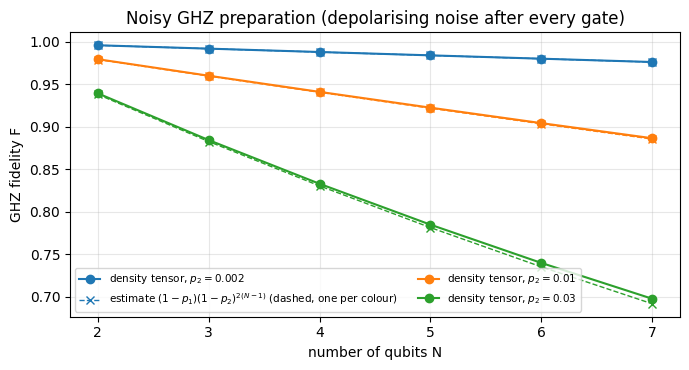

p2=0.002: F(N=7) = 0.9762,  estimate = 0.9761
p2=0.01: F(N=7) = 0.8865,  estimate = 0.8855
p2=0.03: F(N=7) = 0.6977,  estimate = 0.6918


In [28]:
# ==============================================================================
# STEP 16: fidelity of noisy GHZ preparation vs N, compared with the "no error at all" estimate
# ==============================================================================
# PARAMETERS
P1_OVER_P2 = 0.1                                   # single-qubit gates are ~10x better than two-qubit gates
p2_values = (0.002, 0.01, 0.03)
N_values = (2, 3, 4, 5, 6, 7)


def ghz_fidelity(N, p2):
    """Fidelity of the noisily prepared GHZ state with the ideal one (density-tensor simulation, jitted)."""
    gates = strip_labels(ghz_circuit_list(N))
    run = jax.jit(lambda p: fidelity_with_pure(noisy_circuit_dm(to_dm(zero_state(N)), gates, P1_OVER_P2 * p, p),
                                               ghz_state(N)))
    return [float(run(p)) for p in p2]


fig, ax = plt.subplots(figsize=(7, 3.8))
F_table = np.array([ghz_fidelity(n, p2_values) for n in N_values])          # shape (len(N), len(p))
for k, p in enumerate(p2_values):
    estimate = (1 - P1_OVER_P2 * p) * (1 - p) ** (2 * (np.array(N_values) - 1))
    ax.plot(N_values, F_table[:, k], "o-", color=f"C{k}", label=rf"density tensor, $p_2={p}$")
    ax.plot(N_values, estimate, "x--", color=f"C{k}", lw=1,                  # same colour = same p_2
            label=r"estimate $(1-p_1)(1-p_2)^{2(N-1)}$ (dashed, one per colour)" if k == 0 else None)
ax.set_xlabel("number of qubits N")
ax.set_ylabel("GHZ fidelity F")
ax.set_title("Noisy GHZ preparation (depolarising noise after every gate)")
ax.legend(fontsize=7.5, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
for k, p in enumerate(p2_values):
    est = (1 - P1_OVER_P2 * p) * (1 - p) ** (2 * (N_values[-1] - 1))
    print(f"p2={p}: F(N={N_values[-1]}) = {F_table[-1, k]:.4f},  estimate = {est:.4f}")
    assert np.all(F_table[:, k] >= (1 - P1_OVER_P2 * p) * (1 - p) ** (2 * (np.array(N_values) - 1)) - TOL)

The fidelity decays exponentially with the number of gates, and the crude estimate captures the decay well. The exact
fidelity lies slightly *above* it at every point (asserted), and it must: the no-error Kraus operator is
$\sqrt{1-p}\,1$, so $\rho$ contains the ideal state with weight $F_{\rm est}$ plus a positive remainder. The excess comes
from errors that are not fatal. The depolarising channel applies $X$, $Y$ or $Z$ with probability $p/3$ each; an $X$
error on the *last* qubit right after its CNOT is fatal for the GHZ state, but an $X$ error on qubit 0 right after the
Hadamard does nothing at all, because $\lvert+\rangle$ is an eigenstate of $X$; and two $Z$ errors on different qubits
cancel, since $Z_iZ_j$ leaves the GHZ state invariant. Large entangled states therefore require error rates well below
$1/(\text{number of gates})$.

### 10.3 Cross-check with quantum trajectories

The noisy simulator is new, so we test it against an independent method. In notebook 07 we derived an
independent way to simulate a channel: the **stochastic unravelling**. Keep a pure state, and at every noise location
draw one Kraus operator $K_m$ at random with probability $\lVert K_m\lvert\psi\rangle\rVert^2$ (`apply_kraus_mcwf`). Averaging
over many such trajectories reproduces $\rho$; in particular $F=\overline{\lvert\langle\psi_{\rm ideal}\vert\psi_{\rm traj}\rangle\rvert^2}$
with a statistical error $\propto 1/\sqrt{M}$ for $M$ trajectories. One trajectory is a pure function of its PRNG key,
so `vmap` over keys runs all trajectories in parallel.

In [29]:
# ==============================================================================
# CHECKPOINT: density tensor vs M quantum trajectories (vmap over PRNG keys)
# ==============================================================================
def noisy_circuit_mcwf(key, psi, gates, p1, p2):
    """ONE quantum trajectory of the noisy circuit: after every gate, sample a Kraus operator for each touched qubit."""
    for qubits, U in gates:
        psi = apply_gate(psi, U, qubits)
        kraus = kraus_depolarizing(p1 if len(qubits) == 1 else p2)
        for q in qubits:
            key, sub = jax.random.split(key)            # fresh, independent randomness for every noise location
            psi = apply_kraus_mcwf(sub, psi, kraus, [q])
    return psi


N_mc, p2_mc, M_traj = 5, 0.03, 4000
gates_mc = strip_labels(ghz_circuit_list(N_mc))
target = ghz_state(N_mc)

F_dm_of = jax.jit(lambda p1, p2: fidelity_with_pure(noisy_circuit_dm(to_dm(zero_state(N_mc)), gates_mc, p1, p2), target))
F_dm = float(F_dm_of(P1_OVER_P2 * p2_mc, p2_mc))

one_traj = lambda k: fidelity_pure(noisy_circuit_mcwf(k, zero_state(N_mc), gates_mc, P1_OVER_P2 * p2_mc, p2_mc), target)
F_samples = jax.jit(jax.vmap(one_traj))(jax.random.split(jax.random.PRNGKey(11), M_traj))
F_mc, F_err = float(jnp.mean(F_samples)), float(jnp.std(F_samples) / jnp.sqrt(M_traj))
print(f"density tensor : F = {F_dm:.4f}")
print(f"{M_traj} trajectories: F = {F_mc:.4f} +- {F_err:.4f}   (deviation = {abs(F_mc - F_dm) / F_err:.1f} standard errors)")
assert abs(F_mc - F_dm) < 5 * F_err

# WRONG CONTROL: the other common convention rho -> (1-p) rho + p 1/2 (Pauli errors p/4 each) is our channel at 3p/4
F_wrong = float(F_dm_of(0.75 * P1_OVER_P2 * p2_mc, 0.75 * p2_mc))
F_est = (1 - P1_OVER_P2 * p2_mc) * (1 - p2_mc) ** (2 * (N_mc - 1))
print(f"wrong convention (3p/4)  : F = {F_wrong:.4f}  ({abs(F_mc - F_wrong) / F_err:.1f} standard errors away)")
print(f"no-error estimate F_est  : F = {F_est:.4f}  ({abs(F_mc - F_est) / F_err:.1f} standard errors away)")
assert abs(F_mc - F_wrong) > 5 * F_err

density tensor : F = 0.7848
4000 trajectories: F = 0.7807 +- 0.0065   (deviation = 0.6 standard errors)
wrong convention (3p/4)  : F = 0.8339  (8.1 standard errors away)
no-error estimate F_est  : F = 0.7814  (0.1 standard errors away)


The two independent simulations agree within the statistical error. The other common convention of the depolarising
channel, $\rho\to(1-p)\rho+p\,1/2$ (our channel at strength $3p/4$), is rejected by many standard errors, whereas the
exact value and the no-error estimate of Section 10.2 lie within one standard error of each other at $M=4000$. The density
tensor is exact but needs $4^N$ numbers; trajectories need $2^N$ numbers per trajectory and converge as $1/\sqrt M$ -
the method of choice beyond $N\approx13$–$14$, where the density tensor no longer fits into a laptop's memory
([notebook 17](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb), Chapter 6).

### 10.4 The Trotter-step dilemma of noisy digital simulation

On a perfect device the Trotter error falls with the step size (Section 9.2). On a noisy device a smaller step means
*more gates*, hence more noise. We combine the two ingredients: the first-order TFIM Trotter circuit of Section 9,
run on the density tensor with noise $p$ after every gate, compared with the *exact* state
$e^{-iHt}\lvert\psi_0\rangle$.

**JAX detail.** The function below is compiled once and called with many values of `n_steps`. A `lax.scan` needs a
static length, which would trigger a recompilation for each `n_steps`. `lax.fori_loop(0, n_steps, body, rho)` accepts
a *traced* upper bound (it becomes an XLA while-loop), and the gate angles $\propto t/n_{\rm steps}$ are traced as well:
one compilation serves the whole sweep.

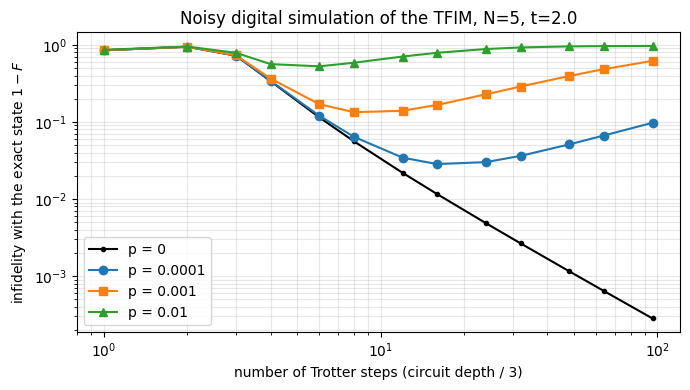

p =       0: best number of steps =  96,  minimal infidelity = 2.82e-04
p =  0.0001: best number of steps =  16,  minimal infidelity = 2.84e-02
p =   0.001: best number of steps =   8,  minimal infidelity = 1.34e-01
p =    0.01: best number of steps =   6,  minimal infidelity = 5.27e-01


In [30]:
# ==============================================================================
# STEP 17: Trotter error vs gate noise -- infidelity with the exact state as a function of the number of steps
# ==============================================================================
# PARAMETERS
N_d, J_d, h_d, t_d = 5, 1.0, 1.0, 2.0
noise_levels = (0.0, 1e-4, 1e-3, 1e-2)               # same error probability after 1- and 2-qubit gates, for simplicity
steps_d = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64, 96])

terms_d = heisenberg_terms(N_d, Jxx=0.0, Jyy=0.0, Jzz=J_d, hx=h_d)
psi_target = exact_evolve(zero_state(N_d), terms_d, t_d)
rho_start = to_dm(zero_state(N_d))


@jax.jit
def noisy_trotter_infidelity(n_steps, p):
    """1 - <psi_exact| rho |psi_exact> after n_steps noisy first-order Trotter steps (n_steps and p are traced)."""
    gates = strip_labels(tfim_trotter_circuit(N_d, J_d, h_d, t_d / n_steps, order=1))
    rho = lax.fori_loop(0, n_steps, lambda i, r: noisy_circuit_dm(r, gates, p, p), rho_start)
    return 1.0 - fidelity_with_pure(rho, psi_target)


fig, ax = plt.subplots(figsize=(7, 4))
best_steps = {}
for p, marker in zip(noise_levels, ("k.-", "o-", "s-", "^-")):
    infid_d = np.array([float(noisy_trotter_infidelity(int(n), p)) for n in steps_d])
    best_steps[p] = (int(steps_d[np.argmin(infid_d)]), float(infid_d.min()))
    ax.loglog(steps_d, infid_d, marker, label=f"p = {p:g}")
ax.set_xlabel("number of Trotter steps (circuit depth / 3)")
ax.set_ylabel(r"infidelity with the exact state $1-F$")
ax.set_title(f"Noisy digital simulation of the TFIM, N={N_d}, t={t_d}")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()
for p, (n_best, val) in best_steps.items():
    print(f"p = {p:7g}: best number of steps = {n_best:3d},  minimal infidelity = {val:.2e}")

Without noise (black) the infidelity decreases monotonically from $n_{\rm steps}=2$ on, $\propto n_{\rm steps}^{-2}$
(steps of size $dt=2$ and $1$ lie far outside the regime of the Trotter expansion). With noise each curve has a
**minimum**: to the left the Trotter error dominates, to the right the accumulated gate noise, which grows linearly
with the number of steps. The optimal number of steps and the best achievable accuracy are printed above: the noisier
the device, the *coarser* the optimal Trotter step and the worse the best result. Balancing the two errors,
$a/n^2 \sim b\,p\,n$, gives $n_{\rm opt}\propto p^{-1/3}$ - this is why digital quantum simulation on present-day
hardware is limited to short times and why higher-order formulas, better gates and error mitigation are active
research fields.

## 11. Summary - key takeaways

* **Qubits are spins, gates are small unitaries, a circuit is a list.** Our spin-chain simulator of notebook 05 *is*
  a circuit simulator: `apply_gates(psi, [(qubits, U), ...])`, cost $O(2^k2^N)$ per $k$-qubit gate, any qubits,
  no SWAPs.
* For any operator with $P^2=1$: $e^{-iaP}=\cos a-i\sin a\,P$. This single formula gives $R_x,R_y,R_z$,
  $R_{xx},R_{yy},R_{zz}$ and the exchange/SWAP gate in closed form - exact, cheap, differentiable.
* Gates are physical: a rotation is a resonant pulse of area $\theta$, $R_{zz}$ is an Ising interaction switched on
  for a time, the Heisenberg exchange at $\tau=\pi/4$ is a SWAP up to a phase. Global phases are irrelevant for a single
  gate; controlling the gate turns them into relative phases between the control branches.
* Compare unitaries with a phase-blind distance; obtain the dense unitary of a small circuit by `vmap`-ing the
  matrix-free action over basis states; verify every identity before using it in a "compiler pass".
* `jax.jit` fuses a whole circuit into one program (structure static, angles and states traced); `vmap` sweeps
  parameters and trajectories; `lax.scan`/`fori_loop` fold repeated layers so that compilation time does not grow
  with depth.
* A Trotter step of a spin Hamiltonian is a constant-depth circuit: $N-1$ two-qubit gates per step, depth 3 for the
  TFIM. Digital quantum simulation = running this circuit on hardware.
* With noise after every gate the fidelity decays exponentially with the gate count; in noisy Trotter simulations
  there is an optimal step size. The density tensor ($4^N$) and quantum trajectories ($2^N\times M$) are two
  consistent ways to simulate this.

## 12. Exercises

1. ★ **Pauli algebra by circuit.** Using `circuit_unitary` verify $XYZ = i\,1$, $HSH \propto R_x(\pi/2)$ (find the
   phase), and $T = e^{i\pi/8}R_z(\pi/4)$. For each, compare both the entry-wise error and `gate_distance`: which of
   the three relations needs the phase factor that is written down, and which would also hold without it?
2. ★ **General rotation axis.** Write `rn(theta, n)` for a unit vector $\mathbf n$ with Eq. (2), check it against
   `expm`, and verify numerically that $H = i\,R_{\mathbf n}(\pi)$ with $\mathbf n=(1,0,1)/\sqrt2$. Plot the Bloch
   vector of $R_{\mathbf n}(\theta)\lvert0\rangle$ for $\theta\in[0,2\pi]$ and interpret the trajectory.
3. ★★ **CZ from $R_{zz}$.** Show analytically and numerically that
   $\mathrm{CZ} = e^{-i\pi/4}\,[R_z(-\pi/2)\otimes R_z(-\pi/2)]\,R_{zz}(\pi/2)$.
   (Hint: all matrices are diagonal; compare the four diagonal entries.)
4. ★★ **Log-depth GHZ (extend the code).** With long-range CNOTs a GHZ state can be prepared in depth
   $\lceil\log_2N\rceil+1$: in every layer, each qubit that already belongs to the GHZ cluster entangles one new qubit.
   Write `ghz_circuit_logdepth(N)`, draw it, confirm the depth with `schedule` and the fidelity with `ghz_state(N)` for
   $N=8, 16$. Then repeat the noise study of Section 10.2 (density tensor, $N\le7$ as there): which circuit gives
   the better GHZ fidelity at equal $p_2$, and why is the answer not obvious? (Add *idle noise* - a depolarising
   channel on every qubit that waits during a layer - to see depth matter.)
5. ★★ **Physics: $\sqrt{\mathrm{SWAP}}$.** Using the exchange formula of Section 7 at $\tau=\pi/8$, construct
   $\sqrt{\mathrm{SWAP}}$ (up to a global phase - check with `gate_distance` against
   $\frac{1+i}{2}1_4+\frac{1-i}{2}\mathrm{SWAP}$, the square root with eigenvalues $1$ and $i$),
   apply it to $\lvert01\rangle$ and compute the entanglement entropy. Verify that two $\sqrt{\rm SWAP}$ gates and
   single-qubit $Z$ rotations suffice to build a CZ (Loss & DiVincenzo 1998):
   $\mathrm{CZ}\propto R_z^{(0)}(\tfrac\pi2)R_z^{(1)}(-\tfrac\pi2)\sqrt{\rm SWAP}\,R_z^{(0)}(\pi)\sqrt{\rm SWAP}$
   (equality up to a global phase: use `gate_distance`).
6. ★★ **XXZ Trotter circuit (extend the code).** Write `xxz_trotter_circuit(N, J, Delta, dt)` for
   $H=J\sum(XX+YY+\Delta ZZ)$ with even/odd bond layers using $R_{xx},R_{yy},R_{zz}$. Check one step against
   `tebd_gates(heisenberg_terms(...), dt, order=1)` with `circuit_unitary`. Careful: unlike in the TFIM, the bond
   terms of the XXZ chain do *not* commute, so the two gate lists agree only if they use the **same order of bonds**;
   pass your even/odd list through the `bonds=` argument of `heisenberg_terms`. (With the default staircase order the
   two unitaries differ by about $4\times10^{-2}$ at $N=4$, $dt=0.1$ - a good thing to see once.) Why is the
   agreement exact *per bond* but the full step still approximate?
   Verify that the circuit conserves $\sum_q\langle Z_q\rangle$ exactly, and explain why the intermediate state after
   a single $R_{xx}$ gate does not.
7. ★★★ **Optimal Trotter step.** Extract $n_{\rm opt}(p)$ from Section 10.4 for six noise levels between $10^{-5}$ and
   $10^{-2}$ and test the prediction $n_{\rm opt}\propto p^{-1/3}$. Repeat with the second-order circuit: derive and
   test the new exponent.
8. ★★★ **Noise as a gradient problem.** `noisy_trotter_infidelity` is differentiable with respect to `p`. Use
   `jax.grad` to compute $\partial(1-F)/\partial p$ for several `n_steps` and show that, once `n_steps` is large
   enough for the Trotter error to be small, it equals the number of noise locations times a constant of order one.
   Determine that constant and explain it. (Evaluate the derivative at a small but *non-zero* $p$, e.g. $p=10^{-7}$:
   the Kraus operators of the depolarising channel contain $\sqrt{p/3}$, whose derivative blows up at $p=0$, so
   `jax.grad` returns `nan` exactly there even though the channel itself is perfectly smooth in $p$. This is a
   common pattern - a square root inside an otherwise smooth parametrisation.)

## 13. References

* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000),
  Chapter 4 (gates, rotations, universality, circuit identities).
* A. Barenco, C. H. Bennett, R. Cleve, D. P. DiVincenzo, N. Margolus, P. Shor, T. Sleator, J. A. Smolin and
  H. Weinfurter, *Elementary gates for quantum computation*, Phys. Rev. A **52**, 3457 (1995).
* S. Lloyd, *Universal quantum simulators*, Science **273**, 1073 (1996).
* D. Loss and D. P. DiVincenzo, *Quantum computation with quantum dots*, Phys. Rev. A **57**, 120 (1998).
* A. Sørensen and K. Mølmer, *Quantum computation with ions in thermal motion*, Phys. Rev. Lett. **82**, 1971 (1999).
* D. Gottesman, *The Heisenberg representation of quantum computers*, arXiv:quant-ph/9807006 (1998).
* K. Matsumoto and K. Amano, *Representation of quantum circuits with Clifford and $\pi/8$ gates*,
  arXiv:0806.3834 (2008).
* C. M. Dawson and M. A. Nielsen, *The Solovay-Kitaev algorithm*, Quantum Inf. Comput. **6**, 81 (2006)
  (the $O(\log^{3.97}(1/\varepsilon))$ gate count quoted in Section 8).
* N. J. Ross and P. Selinger, *Optimal ancilla-free Clifford+T approximation of z-rotations*,
  Quantum Inf. Comput. **16**, 901 (2016) (the typical $T$-count $3\log_2(1/\varepsilon)$ quoted in Section 8).
* J. Preskill, *Quantum computing in the NISQ era and beyond*, Quantum **2**, 79 (2018).

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/